---
## 1.SETUP INICIAL

### 1.1 Librerías

In [3]:
import os
import zipfile
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import random
from PIL import Image
from tqdm.notebook import tqdm

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.ensemble import VotingClassifier
from sklearn.ensemble import StackingClassifier 
from sklearn.model_selection import ParameterGrid, cross_val_score, train_test_split, learning_curve
from sklearn.metrics import (
    confusion_matrix, classification_report, accuracy_score, precision_score,
    recall_score, f1_score, roc_auc_score, roc_curve, auc
    )
from sklearn.multiclass import OneVsRestClassifier

---
## 2.CARGA Y EXPLORACIÓN DE DATOS

### 2.1 Obtener datos

In [4]:
#Hacerlo solo una vez si no está la carpeta
from LHC import experiment_CMS
experiment_CMS(num_img=500, size=64, zip_name="CERN_dataset")

Generando electron:   0%|          | 0/500 [00:00<?, ?it/s]

Generando muon:   0%|          | 0/500 [00:00<?, ?it/s]

Generando proton:   0%|          | 0/500 [00:00<?, ?it/s]

Generando neutrino:   0%|          | 0/500 [00:00<?, ?it/s]

Generando quark:   0%|          | 0/500 [00:00<?, ?it/s]

Generando tau:   0%|          | 0/500 [00:00<?, ?it/s]

Dataset generado con 500 imágenes por clase.
Archivo comprimido: CERN_dataset.zip


### 2.2 Cargar datos

In [5]:
def cargar_datos(zip_path="CERN_dataset.zip", carpeta_salida="CERN_datos", num_por_carpeta=500):
    #1. Proceso para descomprimir el archivo ZIP
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(carpeta_salida)
    X = []
    y = []
    #2. Recorrer las carpetas con las imagenes
    for clase in os.listdir(carpeta_salida):
        clase_path = os.path.join(carpeta_salida, clase)
        if os.path.isdir(clase_path):
            img_names = os.listdir(clase_path)
            if num_por_carpeta is not None:
                img_names = img_names[:num_por_carpeta]
            for img_name in tqdm(img_names, desc=f"Cargando {clase}"):
                img_path = os.path.join(clase_path, img_name)

                # 3. Procedimiento para cargar imagenes en escala de grises
                img = Image.open(img_path).convert("L")
                X.append(np.array(img))
                y.append(clase)  # etiqueta = nombre de la carpeta

    X = np.array(X)
    return X, y

X, y = cargar_datos("CERN_dataset.zip", num_por_carpeta=500)  # Aumentar a 200 para reducir overfitting
print(f"Se cargaron {len(X)} imágenes.")
print(f"Clases encontradas: {set(y)}")
print("Dimensiones de las imágenes:", X.shape)

Cargando electron:   0%|          | 0/500 [00:00<?, ?it/s]

Cargando muon:   0%|          | 0/500 [00:00<?, ?it/s]

Cargando neutrino:   0%|          | 0/500 [00:00<?, ?it/s]

Cargando proton:   0%|          | 0/500 [00:00<?, ?it/s]

Cargando quark:   0%|          | 0/500 [00:00<?, ?it/s]

Cargando tau:   0%|          | 0/500 [00:00<?, ?it/s]

Se cargaron 3000 imágenes.
Clases encontradas: {'electron', 'tau', 'muon', 'neutrino', 'proton', 'quark'}
Dimensiones de las imágenes: (3000, 64, 64)


### 2.3 Exploración visual

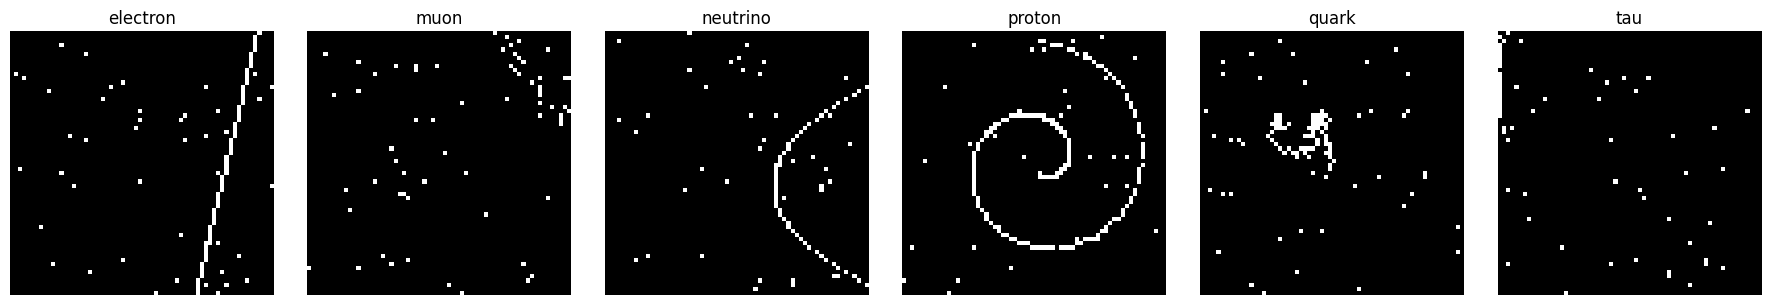

In [6]:
# Mostrar una imagen de cada clase
clases = sorted(list(set(y)))
fig, axs = plt.subplots(1, len(clases), figsize=(3*len(clases), 3))
for i, clase in enumerate(clases):
    idxs = [j for j, label in enumerate(y) if label == clase]
    idx = random.choice(idxs)  # índice aleatorio de la clase
    axs[i].imshow(X[idx], cmap='gray')
    axs[i].set_title(clase)
    axs[i].axis('off')
plt.tight_layout()
plt.show()

---
## 3. PREPROCESAMIENTO

### 3.1 Aplanar imágenes

In [7]:
print('Shape original:', X.shape)
X_flat = X.reshape(X.shape[0], -1)
print('Shape aplanado:', X_flat.shape)

Shape original: (3000, 64, 64)
Shape aplanado: (3000, 4096)


### 3.2 División Train/Test

In [8]:
X_train, X_test, y_train, y_test = train_test_split(X_flat, y, test_size=0.2, random_state=42, stratify=y)

### 3.3 Escalado (StandardScaler)

In [9]:
# Escalado de datos (fit solo en train, transform en test)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
print('Shape escalado train:', X_train_scaled.shape)
print('Shape escalado test:', X_test_scaled.shape)

Shape escalado train: (2400, 4096)
Shape escalado test: (600, 4096)


### 3.4 Análisis PCA exploratorio

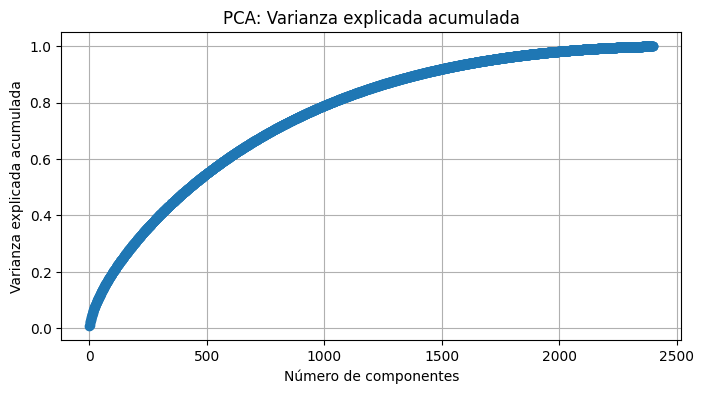

Componentes necesarios para 25% varianza: 144


In [10]:
# Análisis exploratorio de PCA
pca = PCA()
pca.fit(X_train_scaled)
varianza_acumulada = np.cumsum(pca.explained_variance_ratio_)
plt.figure(figsize=(8,4))
plt.plot(varianza_acumulada, marker='o')
plt.xlabel('Número de componentes')
plt.ylabel('Varianza explicada acumulada')
plt.title('PCA: Varianza explicada acumulada')
plt.grid(True)
plt.show()
n_opt = np.argmax(varianza_acumulada >= 0.25) + 1
print(f'Componentes necesarios para 25% varianza: {n_opt}')

Evaluando impacto de reducción de dimensionalidad...



Variando % varianza:   0%|          | 0/6 [00:00<?, ?it/s]


IMPACTO DE LA REDUCCIÓN DE DIMENSIONALIDAD
 varianza_%  n_componentes  acc_train  acc_test     diff
       25.0            144   0.682917  0.613333 0.069583
       50.0            428   0.816667  0.578333 0.238333
       75.0            895   0.988750  0.558333 0.430417
       90.0           1401   1.000000  0.538333 0.461667
       95.0           1695   1.000000  0.541667 0.458333
       99.0           2128   1.000000  0.538333 0.461667


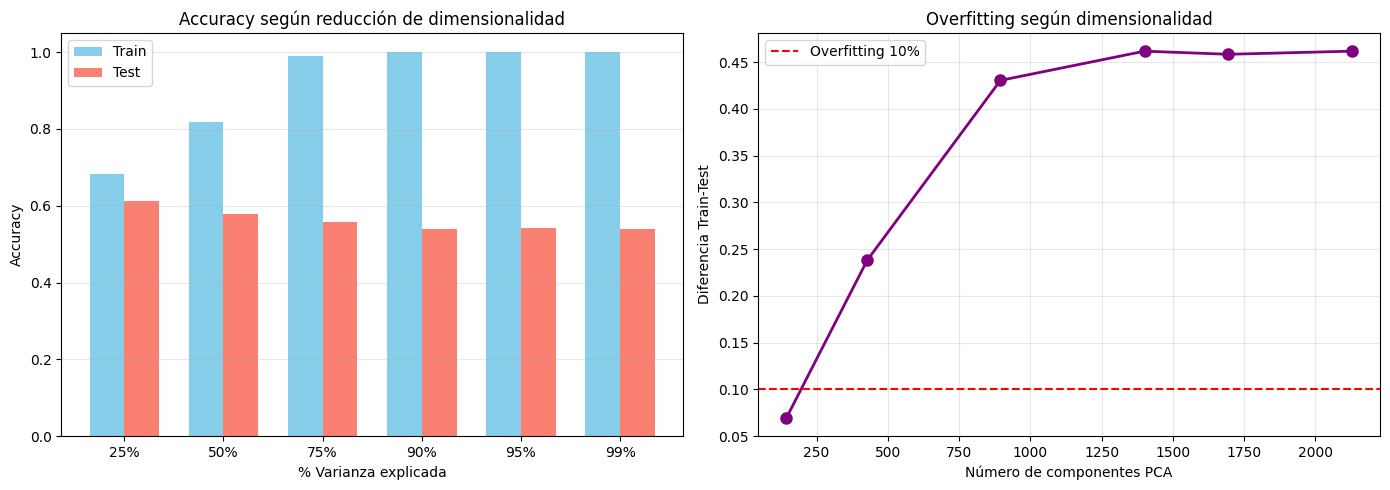


💡 Mejor balance (menor overfitting): 25% varianza
   → 144 componentes
   → Test accuracy: 0.6133
   → Diferencia: 0.0696


In [11]:
# Análisis del impacto de reducción de dimensionalidad
# Evaluar accuracy en test variando el % de varianza explicada
from sklearn.linear_model import LogisticRegression as LR

varianzas_pct = [0.25, 0.50, 0.75, 0.90, 0.95, 0.99]
resultados_dim = []

print("Evaluando impacto de reducción de dimensionalidad...\n")
for var_pct in tqdm(varianzas_pct, desc="Variando % varianza"):
    # Pipeline simple con PCA + LogReg
    pipe_test = Pipeline([
        ('scaler', StandardScaler()),
        ('pca', PCA(n_components=var_pct)),
        ('clf', LR(C=0.01, penalty='l2', solver='saga', max_iter=3000, random_state=42))
    ])
    
    # Entrenar
    pipe_test.fit(X_train, y_train)
    
    # Evaluar
    y_pred_test = pipe_test.predict(X_test)
    y_pred_train = pipe_test.predict(X_train)
    
    acc_train = accuracy_score(y_train, y_pred_train)
    acc_test = accuracy_score(y_test, y_pred_test)
    n_components = pipe_test.named_steps['pca'].n_components_
    
    resultados_dim.append({
        'varianza_%': var_pct * 100,
        'n_componentes': n_components,
        'acc_train': acc_train,
        'acc_test': acc_test,
        'diff': acc_train - acc_test
    })

# Crear DataFrame de resultados
df_dim = pd.DataFrame(resultados_dim)
print("\n" + "="*70)
print("IMPACTO DE LA REDUCCIÓN DE DIMENSIONALIDAD")
print("="*70)
print(df_dim.to_string(index=False))
print("="*70)

# Gráfico de barras comparativo
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Subplot 1: Accuracy train vs test
x = np.arange(len(df_dim))
width = 0.35
axes[0].bar(x - width/2, df_dim['acc_train'], width, label='Train', color='skyblue')
axes[0].bar(x + width/2, df_dim['acc_test'], width, label='Test', color='salmon')
axes[0].set_xlabel('% Varianza explicada')
axes[0].set_ylabel('Accuracy')
axes[0].set_title('Accuracy según reducción de dimensionalidad')
axes[0].set_xticks(x)
axes[0].set_xticklabels([f"{int(v)}%" for v in df_dim['varianza_%']])
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

# Subplot 2: Número de componentes vs diferencia train-test
axes[1].plot(df_dim['n_componentes'], df_dim['diff'], 'o-', color='purple', linewidth=2, markersize=8)
axes[1].axhline(y=0.10, color='red', linestyle='--', label='Overfitting 10%')
axes[1].set_xlabel('Número de componentes PCA')
axes[1].set_ylabel('Diferencia Train-Test')
axes[1].set_title('Overfitting según dimensionalidad')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\n💡 Mejor balance (menor overfitting): {df_dim.loc[df_dim['diff'].idxmin(), 'varianza_%']:.0f}% varianza")
print(f"   → {df_dim.loc[df_dim['diff'].idxmin(), 'n_componentes']:.0f} componentes")
print(f"   → Test accuracy: {df_dim.loc[df_dim['diff'].idxmin(), 'acc_test']:.4f}")
print(f"   → Diferencia: {df_dim.loc[df_dim['diff'].idxmin(), 'diff']:.4f}")

---
## 4. MODELOS DE MACHINE LEARNING

### FUNCIÓN AUXILIAR: Evaluar Overfitting

In [ ]:
def evaluar_overfitting(model, X_train, X_test, y_train, y_test, model_name):
    """
    Evalúa overfitting comparando métricas de train y test y grafica resultados.
    """
    # Predicciones
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)
    # Métricas
    train_acc = accuracy_score(y_train, y_train_pred)
    test_acc = accuracy_score(y_test, y_test_pred)
    train_f1 = f1_score(y_train, y_train_pred, average='weighted')
    test_f1 = f1_score(y_test, y_test_pred, average='weighted')
    # Diferencias
    acc_diff = train_acc - test_acc
    f1_diff = train_f1 - test_f1
    print(f"\n{'='*50}")
    print(f"Evaluación de Overfitting: {model_name}")
    print(f"{'='*50}")
    print(f"Accuracy Train: {train_acc:.4f} | Test: {test_acc:.4f} | Diff: {acc_diff:.4f}")
    print(f"F1-Score Train: {train_f1:.4f} | Test: {test_f1:.4f} | Diff: {f1_diff:.4f}")
    if acc_diff > 0.1:
        print("OVERFITTING (diferencia >10%)")
    elif acc_diff < 0.05:
        print("Buen balance entre train y test")
    else:
        print("Posible overfitting leve")
    # Gráfica comparativa
    metrics = ['Accuracy', 'F1-Score']
    train_scores = [train_acc, train_f1]
    test_scores = [test_acc, test_f1]
    x = np.arange(len(metrics))
    width = 0.35
    fig, ax = plt.subplots(figsize=(8, 5))
    ax.bar(x - width/2, train_scores, width, label='Train', color='skyblue')
    ax.bar(x + width/2, test_scores, width, label='Test', color='salmon')
    ax.set_ylabel('Score')
    ax.set_title(f'Train vs Test - {model_name}')
    ax.set_xticks(x)
    ax.set_xticklabels(metrics)
    ax.legend()
    ax.set_ylim([0, 1])
    plt.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.show()

---
### 4.1 🟦 REGRESIÓN LOGÍSTICA

#### 4.1.1 Hiperparámetros manuales

In [ ]:
logreg_C = 0.01  
logreg_penalty = 'l2'
logreg_solver = 'saga' 

#### 4.1.2 Pipeline + Entrenamiento

In [ ]:
# Pipeline y entrenamiento de regresión logística
pipe_logreg = Pipeline([
    ('scaler', StandardScaler()),
    ('pca', PCA(n_components=0.50)),
    ('clf', LogisticRegression(C=logreg_C, penalty=logreg_penalty, solver=logreg_solver, max_iter=10000, random_state=42))
])
pipe_logreg.fit(X_train, y_train)

# Validación cruzada (CV) - usa el mismo criterio de 50% de varianza
pipe_logreg_cv = Pipeline([
    ('scaler', StandardScaler()),
    ('pca', PCA(n_components=0.50)),
    ('clf', LogisticRegression(C=logreg_C, penalty=logreg_penalty, solver=logreg_solver, max_iter=10000, random_state=42))
])
cv_scores = cross_val_score(pipe_logreg_cv, X_train, y_train, cv=5, scoring='accuracy')
print(f'Accuracy CV (5 folds): {cv_scores.mean():.4f}')

# Pipelines adicionales para comparación de curvas de aprendizaje
pipe_logreg_25 = Pipeline([
    ('scaler', StandardScaler()),
    ('pca', PCA(n_components=0.25)),
    ('clf', LogisticRegression(C=logreg_C, penalty=logreg_penalty, solver=logreg_solver, max_iter=10000, random_state=42))
])

pipe_logreg_95 = Pipeline([
    ('scaler', StandardScaler()),
    ('pca', PCA(n_components=0.95)),
    ('clf', LogisticRegression(C=logreg_C, penalty=logreg_penalty, solver=logreg_solver, max_iter=10000, random_state=42))
])

pipe_logreg_99 = Pipeline([
    ('scaler', StandardScaler()),
    ('pca', PCA(n_components=0.99)),
    ('clf', LogisticRegression(C=logreg_C, penalty=logreg_penalty, solver=logreg_solver, max_iter=10000, random_state=42))
])

Accuracy CV (5 folds): 0.5704


#### 4.1.3 Evaluación completa

In [ ]:
# Evaluación completa de regresión logística (solo métricas)
y_pred = pipe_logreg.predict(X_test)
y_train_pred = pipe_logreg.predict(X_train)

acc_test = accuracy_score(y_test, y_pred)
acc_train = accuracy_score(y_train, y_train_pred)

print(f'Accuracy en train: {acc_train:.4f}')
print(f'Accuracy en test: {acc_test:.4f}')
print(f'Accuracy CV (5 folds): {cv_scores.mean():.4f}')
print('\nReporte de clasificación:')
print(classification_report(y_test, y_pred))

Accuracy en train: 0.8750
Accuracy en test: 0.5250
Accuracy CV (5 folds): 0.5604

Reporte de clasificación:
              precision    recall  f1-score   support

    electron       0.31      0.20      0.24        20
        muon       0.31      0.40      0.35        20
    neutrino       0.35      0.40      0.37        20
      proton       1.00      1.00      1.00        20
       quark       0.90      0.95      0.93        20
         tau       0.24      0.20      0.22        20

    accuracy                           0.53       120
   macro avg       0.52      0.53      0.52       120
weighted avg       0.52      0.53      0.52       120



#### 4.1.4 Matriz de confusión

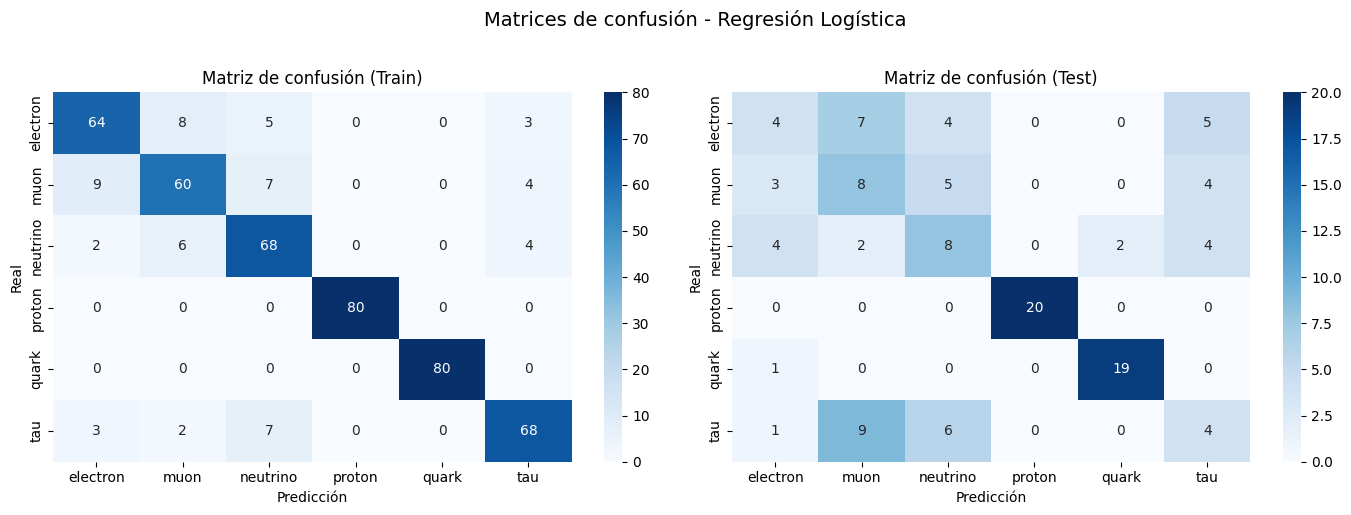

In [ ]:
# Matriz de confusión - LogReg (Train y Test juntas)
cm_train = confusion_matrix(y_train, y_train_pred, labels=pipe_logreg.classes_)
cm_test = confusion_matrix(y_test, y_pred, labels=pipe_logreg.classes_)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Matriz de confusión Train
sns.heatmap(cm_train, annot=True, fmt='d', cmap='Blues', 
            xticklabels=pipe_logreg.classes_, yticklabels=pipe_logreg.classes_, ax=axes[0])
axes[0].set_xlabel('Predicción')
axes[0].set_ylabel('Real')
axes[0].set_title('Matriz de confusión (Train)')

# Matriz de confusión Test
sns.heatmap(cm_test, annot=True, fmt='d', cmap='Blues', 
            xticklabels=pipe_logreg.classes_, yticklabels=pipe_logreg.classes_, ax=axes[1])
axes[1].set_xlabel('Predicción')
axes[1].set_ylabel('Real')
axes[1].set_title('Matriz de confusión (Test)')

plt.suptitle('Matrices de confusión - Regresión Logística', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

#### 4.1.5 Curva de aprendizaje

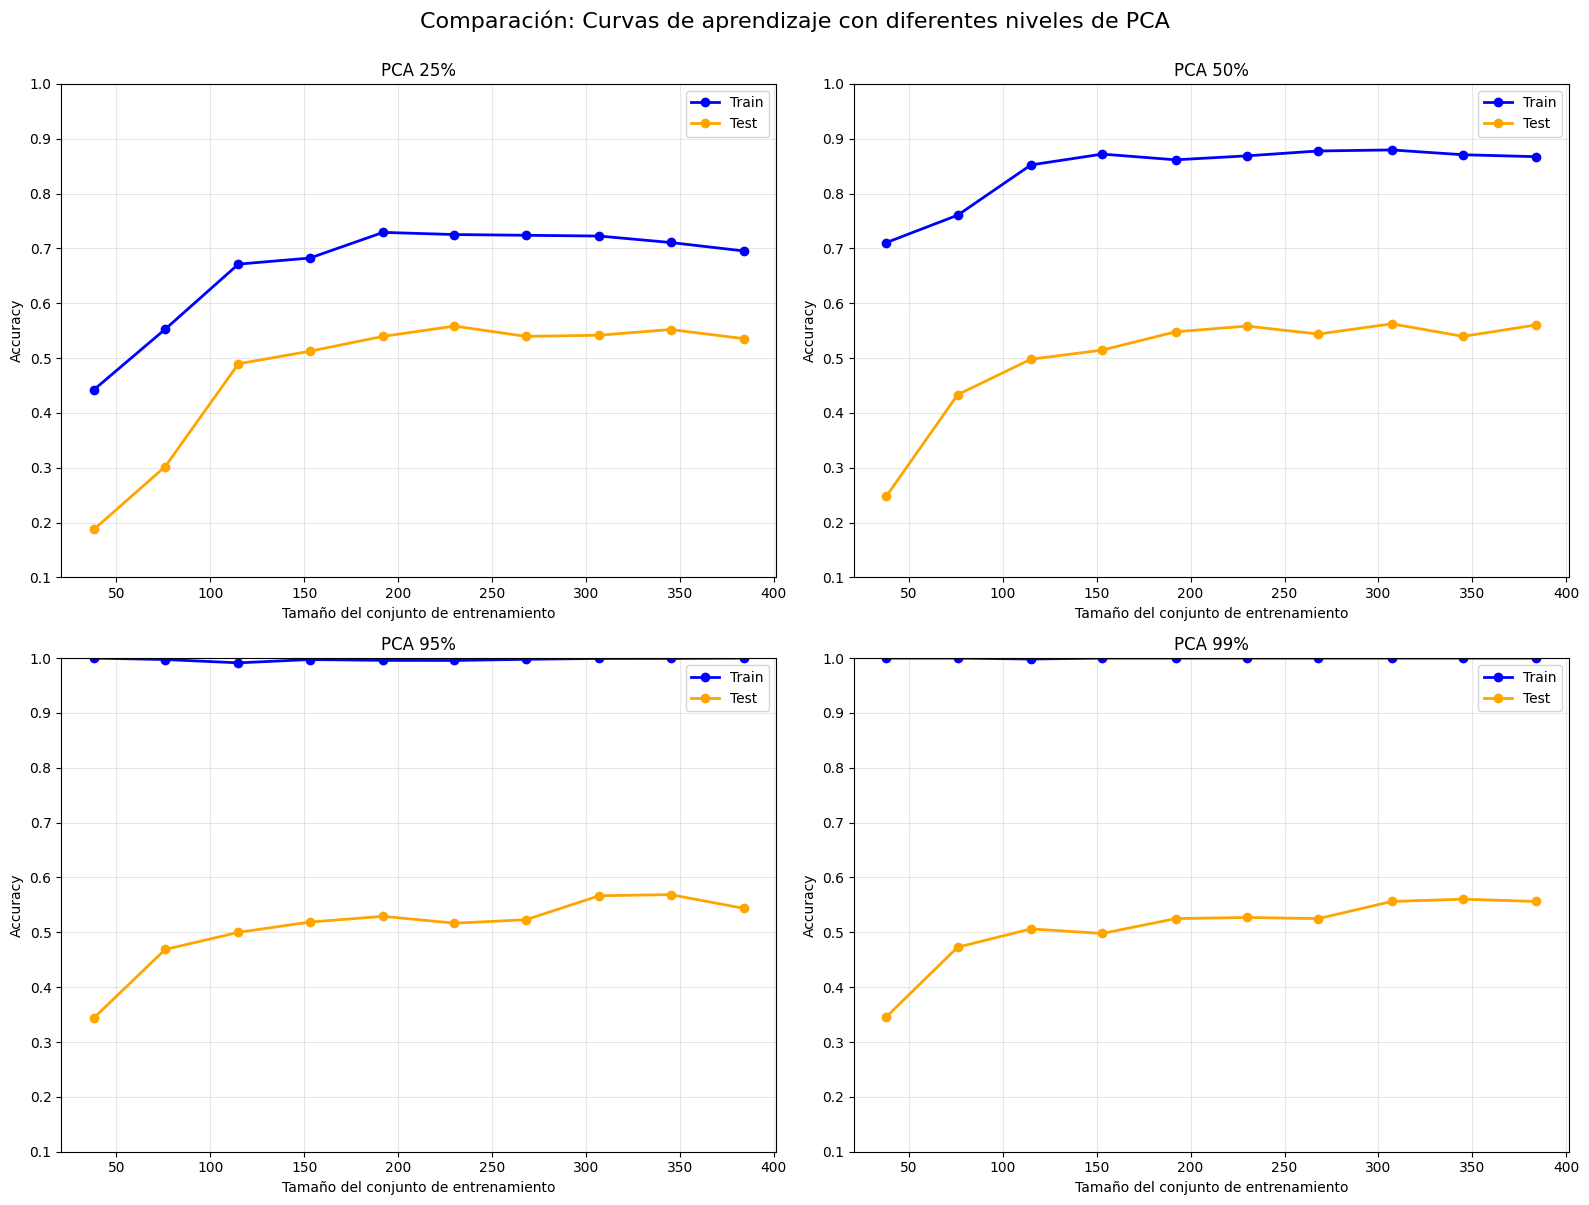

In [ ]:
# Curva de aprendizaje comparativa: PCA 50%, 25%, 95%, 99%

# Calcular curvas con PCA 50% (actual)
train_sizes_50, train_scores_50, test_scores_50 = learning_curve(
    pipe_logreg_cv, X_train, y_train, cv=5, 
    train_sizes=np.linspace(0.1, 1.0, 10), 
    scoring='accuracy'
)

# Calcular curvas con PCA 25%
train_sizes_25, train_scores_25, test_scores_25 = learning_curve(
    pipe_logreg_25, X_train, y_train, cv=5, 
    train_sizes=np.linspace(0.1, 1.0, 10), 
    scoring='accuracy'
)

# Calcular curvas con PCA 95%
train_sizes_95, train_scores_95, test_scores_95 = learning_curve(
    pipe_logreg_95, X_train, y_train, cv=5, 
    train_sizes=np.linspace(0.1, 1.0, 10), 
    scoring='accuracy'
)

# Calcular curvas con PCA 99%
train_sizes_99, train_scores_99, test_scores_99 = learning_curve(
    pipe_logreg_99, X_train, y_train, cv=5, 
    train_sizes=np.linspace(0.1, 1.0, 10), 
    scoring='accuracy'
)

train_mean_50 = train_scores_50.mean(axis=1)
test_mean_50 = test_scores_50.mean(axis=1)
train_mean_25 = train_scores_25.mean(axis=1)
test_mean_25 = test_scores_25.mean(axis=1)
train_mean_95 = train_scores_95.mean(axis=1)
test_mean_95 = test_scores_95.mean(axis=1)
train_mean_99 = train_scores_99.mean(axis=1)
test_mean_99 = test_scores_99.mean(axis=1)

# Gráfico comparativo 2x2
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Subplot 1: PCA 25%
axes[0, 0].plot(train_sizes_25, train_mean_25, 'o-', label='Train', color='blue', linewidth=2)
axes[0, 0].plot(train_sizes_25, test_mean_25, 'o-', label='Test', color='orange', linewidth=2)
axes[0, 0].set_xlabel('Tamaño del conjunto de entrenamiento')
axes[0, 0].set_ylabel('Accuracy')
axes[0, 0].set_title('PCA 25%')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)
axes[0, 0].set_ylim([0.1, 1.0])

# Subplot 2: PCA 50%
axes[0, 1].plot(train_sizes_50, train_mean_50, 'o-', label='Train', color='blue', linewidth=2)
axes[0, 1].plot(train_sizes_50, test_mean_50, 'o-', label='Test', color='orange', linewidth=2)
axes[0, 1].set_xlabel('Tamaño del conjunto de entrenamiento')
axes[0, 1].set_ylabel('Accuracy')
axes[0, 1].set_title('PCA 50%')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)
axes[0, 1].set_ylim([0.1, 1.0])

# Subplot 3: PCA 95%
axes[1, 0].plot(train_sizes_95, train_mean_95, 'o-', label='Train', color='blue', linewidth=2)
axes[1, 0].plot(train_sizes_95, test_mean_95, 'o-', label='Test', color='orange', linewidth=2)
axes[1, 0].set_xlabel('Tamaño del conjunto de entrenamiento')
axes[1, 0].set_ylabel('Accuracy')
axes[1, 0].set_title('PCA 95%')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)
axes[1, 0].set_ylim([0.1, 1.0])

# Subplot 4: PCA 99%
axes[1, 1].plot(train_sizes_99, train_mean_99, 'o-', label='Train', color='blue', linewidth=2)
axes[1, 1].plot(train_sizes_99, test_mean_99, 'o-', label='Test', color='orange', linewidth=2)
axes[1, 1].set_xlabel('Tamaño del conjunto de entrenamiento')
axes[1, 1].set_ylabel('Accuracy')
axes[1, 1].set_title('PCA 99%')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)
axes[1, 1].set_ylim([0.1, 1.0])

plt.suptitle('Comparación: Curvas de aprendizaje con diferentes niveles de PCA', fontsize=16, y=1.00)
plt.tight_layout()
plt.show()

#### 4.1.6 Curvas ROC-AUC

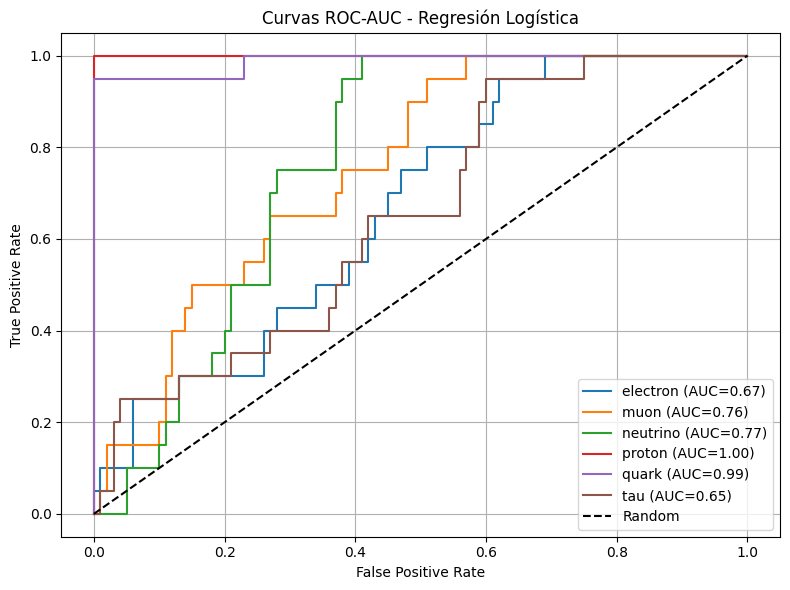

In [ ]:
# Curvas ROC-AUC - LogReg
y_test_bin = label_binarize(y_test, classes=pipe_logreg.classes_)
y_score = pipe_logreg.predict_proba(X_test)

fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(len(pipe_logreg.classes_)):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

plt.figure(figsize=(8, 6))
for i, clase in enumerate(pipe_logreg.classes_):
    plt.plot(fpr[i], tpr[i], label=f'{clase} (AUC={roc_auc[i]:.2f})')

plt.plot([0, 1], [0, 1], 'k--', label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Curvas ROC-AUC - Regresión Logística')
plt.legend(loc='lower right')
plt.grid(True)
plt.tight_layout()
plt.show()

#### 4.1.7 Análisis de overfitting


Evaluación de Overfitting: Regresión Logística
Accuracy Train: 0.8246 | Test: 0.5983 | Diff: 0.2262
F1-Score Train: 0.8246 | Test: 0.5968 | Diff: 0.2279
OVERFITTING (diferencia >10%)


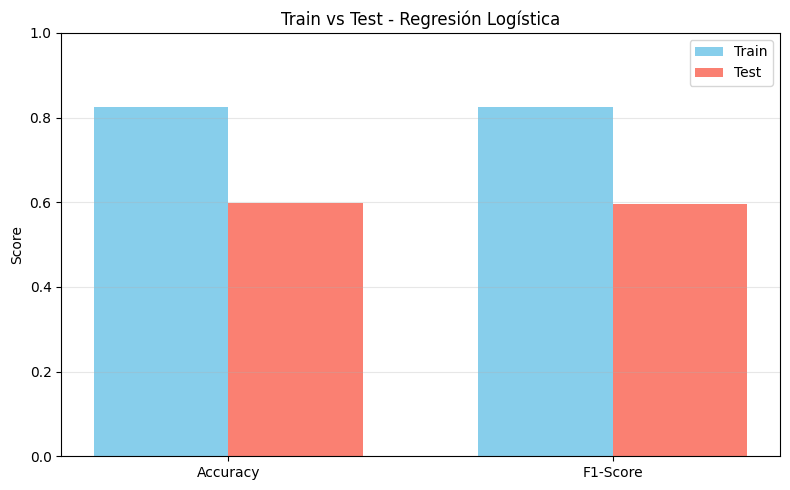

In [ ]:
# Análisis de overfitting - LogReg
evaluar_overfitting(pipe_logreg, X_train, X_test, y_train, y_test, "Regresión Logística")

---
### 4.2 🟨 SVM (RBF Kernel)

#### 4.2.1 Hiperparámetros manuales

#### 4.2.2 Pipeline + Entrenamiento

#### 4.2.3 Evaluación completa

#### 4.2.4 Matriz de confusión

#### 4.2.5 Curva de aprendizaje

#### 4.2.6 Curvas ROC-AUC

#### 4.2.7 Análisis de overfitting

---
### 4.3 🟦 K-NEAREST NEIGHBORS (KNN)

#### 4.3.1 Hiperparámetros y Entrenamiento

In [ ]:
KNN_PARAMS = {
    'n_neighbors': np.int64(5),  # k = 5
    'weights': 'uniform',
    'metric': 'euclidean'
}

pipe_knn = Pipeline([
    ('scaler', StandardScaler()),
    ('pca', PCA(n_components=0.50)),
    ('clf', KNeighborsClassifier(**KNN_PARAMS)) 
])
pipe_knn.fit(X_train, y_train)
pipe_knn_cv = Pipeline([
    ('scaler', StandardScaler()),
    ('pca', PCA(n_components=0.50)),
    ('clf', KNeighborsClassifier(**KNN_PARAMS))
])
cv_scores = cross_val_score(pipe_knn_cv, X_train, y_train, cv=5, scoring='accuracy', n_jobs=-1) 
print(f'Accuracy CV (5 folds): {cv_scores.mean():.4f}')

# 3. Pipelines adicionales para comparación de curvas de aprendizaje (diferentes umbrales de PCA)
pipe_knn_25 = Pipeline([
    ('scaler', StandardScaler()),
    ('pca', PCA(n_components=0.25)),
    ('clf', KNeighborsClassifier(**KNN_PARAMS))
])

pipe_knn_95 = Pipeline([
    ('scaler', StandardScaler()),
    ('pca', PCA(n_components=0.95)),
    ('clf', KNeighborsClassifier(**KNN_PARAMS))
])

pipe_knn_99 = Pipeline([
    ('scaler', StandardScaler()),
    ('pca', PCA(n_components=0.99)),
    ('clf', KNeighborsClassifier(**KNN_PARAMS))
])

Accuracy CV (5 folds): 0.3392


#### 4.3.2 Evaluación y Métricas

In [ ]:

y_pred = pipe_knn.predict(X_test)
y_train_pred = pipe_knn.predict(X_train)


acc_test = accuracy_score(y_test, y_pred)
acc_train = accuracy_score(y_train, y_train_pred)

print(f'Accuracy en train: {acc_train:.4f}')
print(f'Accuracy en test: {acc_test:.4f}')
print(f'Accuracy CV (5 folds): {cv_scores.mean():.4f}') 
print('\nReporte de clasificación:')

print(classification_report(y_test, y_pred))

Accuracy en train: 0.5492
Accuracy en test: 0.3583
Accuracy CV (5 folds): 0.3392

Reporte de clasificación:
              precision    recall  f1-score   support

    electron       0.22      0.45      0.29       100
        muon       0.24      0.71      0.36       100
    neutrino       0.00      0.00      0.00       100
      proton       1.00      0.01      0.02       100
       quark       0.98      0.96      0.97       100
         tau       0.50      0.02      0.04       100

    accuracy                           0.36       600
   macro avg       0.49      0.36      0.28       600
weighted avg       0.49      0.36      0.28       600



c:\Users\leon9\OneDrive\Desktop\Fisica\Mineria\parcial2\p2\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\leon9\OneDrive\Desktop\Fisica\Mineria\parcial2\p2\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\leon9\OneDrive\Desktop\Fisica\Mineria\parcial2\p2\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _

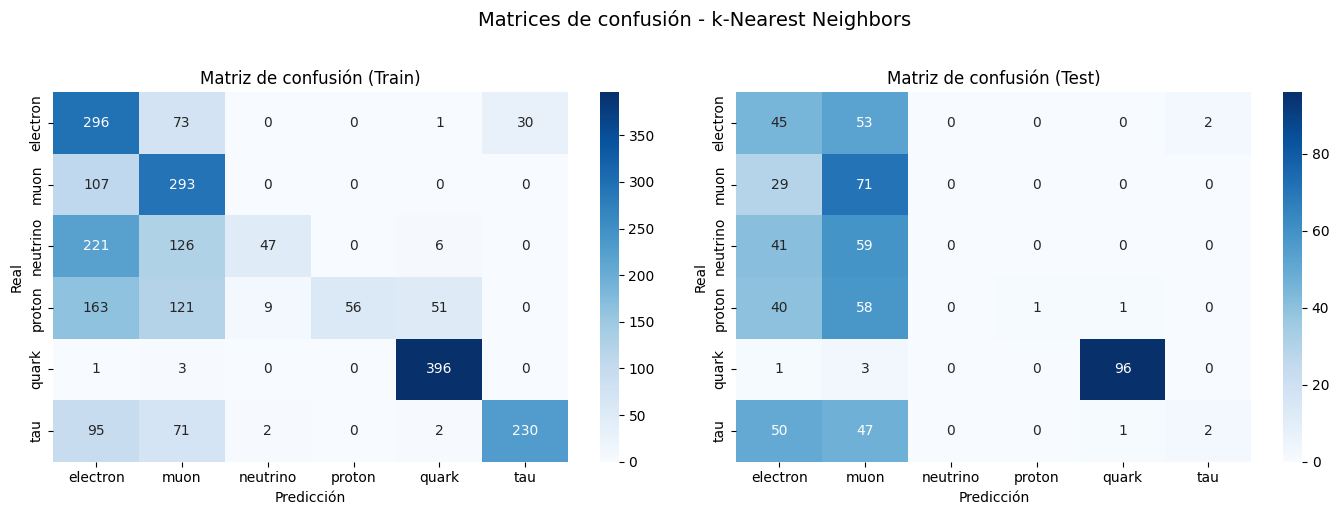

In [ ]:
class_names = sorted(list(set(y))) 

# Matriz de confusión Train y Test
cm_train = confusion_matrix(y_train, y_train_pred, labels=class_names)
cm_test = confusion_matrix(y_test, y_pred, labels=class_names)

# Creamos la figura con dos subgráficos
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Matriz de confusión Train
sns.heatmap(cm_train, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_names, yticklabels=class_names, ax=axes[0])
axes[0].set_xlabel('Predicción')
axes[0].set_ylabel('Real')
axes[0].set_title('Matriz de confusión (Train)')

# 2. Matriz de confusión Test
sns.heatmap(cm_test, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_names, yticklabels=class_names, ax=axes[1])
axes[1].set_xlabel('Predicción')
axes[1].set_ylabel('Real')
axes[1].set_title('Matriz de confusión (Test)')

# Título general actualizado
plt.suptitle('Matrices de confusión - k-Nearest Neighbors', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

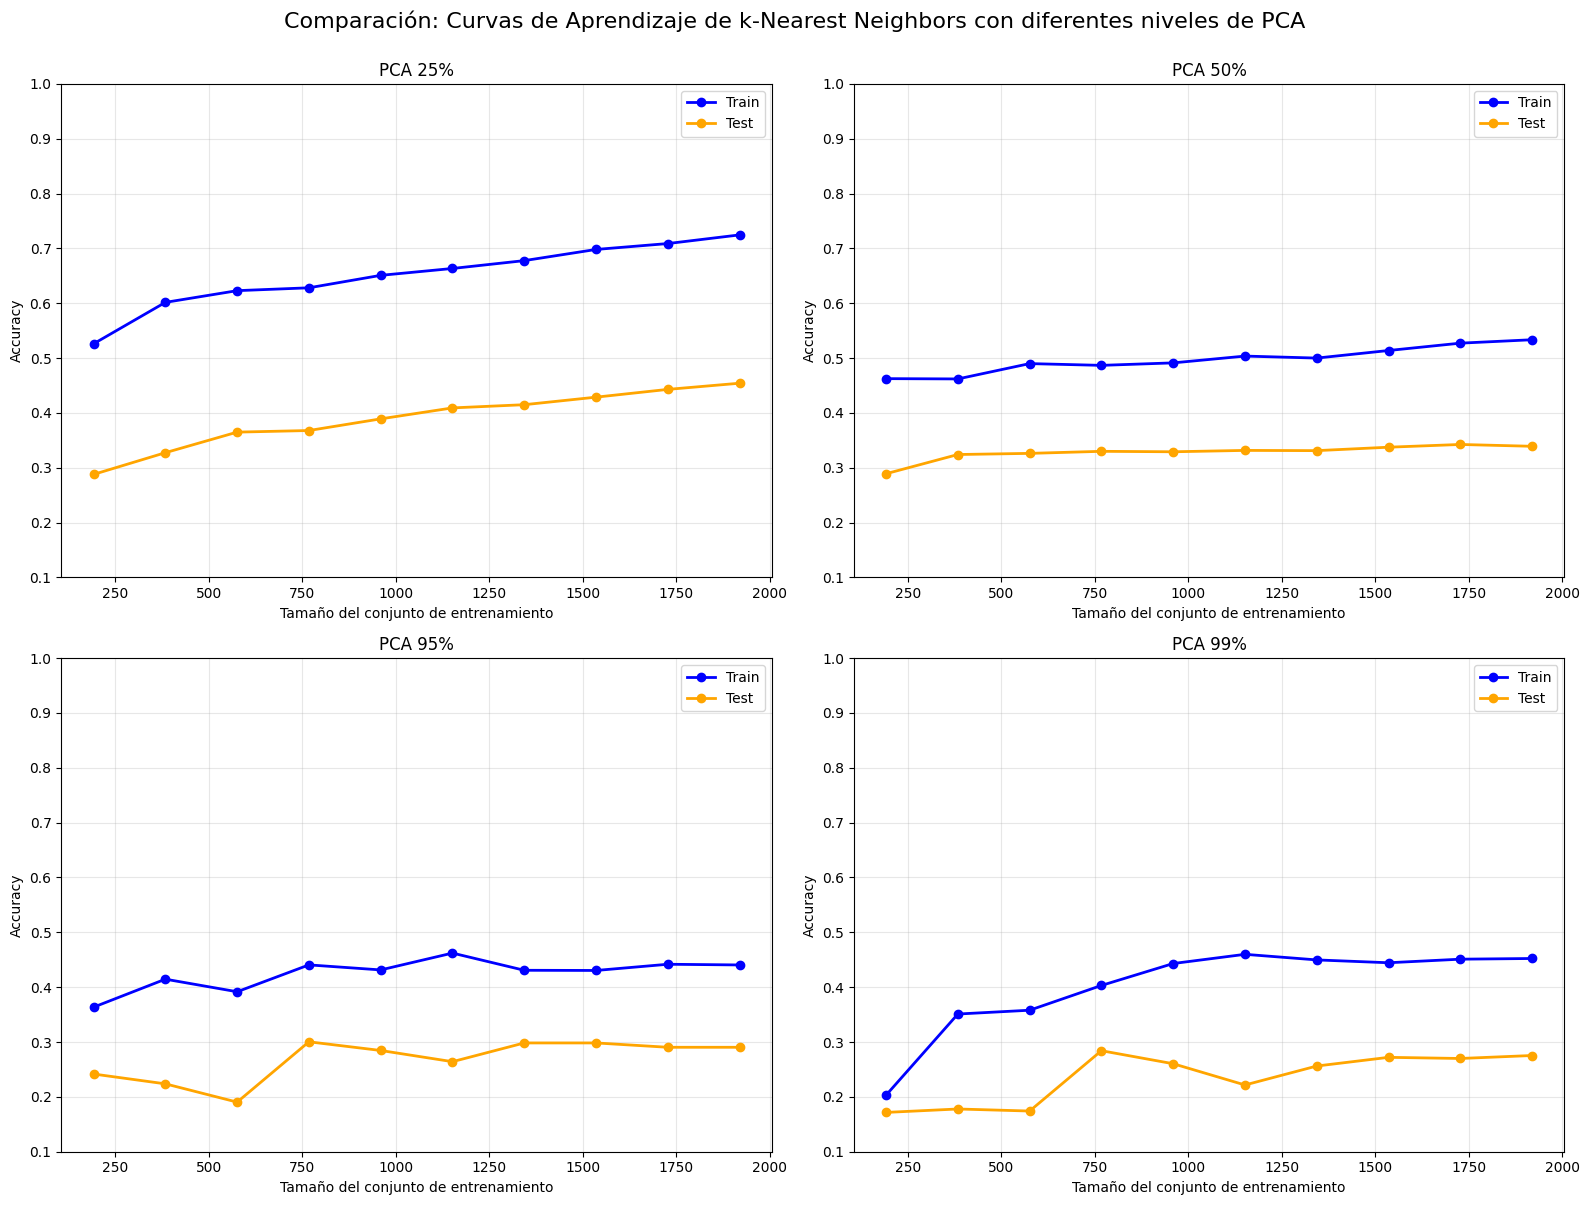

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import learning_curve
# Nota: Asume que pipe_knn_cv, pipe_knn_25, pipe_knn_95, pipe_knn_99, X_train, y_train están definidos.

# --- 1. Calcular curvas con diferentes niveles de PCA ---

# Calcular curvas con PCA 50% (actual)
train_sizes_50, train_scores_50, test_scores_50 = learning_curve(
    pipe_knn_cv, X_train, y_train, cv=5, 
    train_sizes=np.linspace(0.1, 1.0, 10), 
    scoring='accuracy', n_jobs=-1
)

# Calcular curvas con PCA 25%
train_sizes_25, train_scores_25, test_scores_25 = learning_curve(
    pipe_knn_25, X_train, y_train, cv=5, 
    train_sizes=np.linspace(0.1, 1.0, 10), 
    scoring='accuracy', n_jobs=-1
)

# Calcular curvas con PCA 95%
train_sizes_95, train_scores_95, test_scores_95 = learning_curve(
    pipe_knn_95, X_train, y_train, cv=5, 
    train_sizes=np.linspace(0.1, 1.0, 10), 
    scoring='accuracy', n_jobs=-1
)

# Calcular curvas con PCA 99%
train_sizes_99, train_scores_99, test_scores_99 = learning_curve(
    pipe_knn_99, X_train, y_train, cv=5, 
    train_sizes=np.linspace(0.1, 1.0, 10), 
    scoring='accuracy', n_jobs=-1
)

# --- 2. Promediar los scores ---
train_mean_50 = train_scores_50.mean(axis=1)
test_mean_50 = test_scores_50.mean(axis=1)
train_mean_25 = train_scores_25.mean(axis=1)
test_mean_25 = test_scores_25.mean(axis=1)
train_mean_95 = train_scores_95.mean(axis=1)
test_mean_95 = test_scores_95.mean(axis=1)
train_mean_99 = train_scores_99.mean(axis=1)
test_mean_99 = test_scores_99.mean(axis=1)

# --- 3. Gráfico comparativo 2x2 ---
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Subplot 1: PCA 25%
axes[0, 0].plot(train_sizes_25, train_mean_25, 'o-', label='Train', color='blue', linewidth=2)
axes[0, 0].plot(train_sizes_25, test_mean_25, 'o-', label='Test', color='orange', linewidth=2)
axes[0, 0].set_xlabel('Tamaño del conjunto de entrenamiento')
axes[0, 0].set_ylabel('Accuracy')
axes[0, 0].set_title('PCA 25%')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)
axes[0, 0].set_ylim([0.1, 1.0])

# Subplot 2: PCA 50%
axes[0, 1].plot(train_sizes_50, train_mean_50, 'o-', label='Train', color='blue', linewidth=2)
axes[0, 1].plot(train_sizes_50, test_mean_50, 'o-', label='Test', color='orange', linewidth=2)
axes[0, 1].set_xlabel('Tamaño del conjunto de entrenamiento')
axes[0, 1].set_ylabel('Accuracy')
axes[0, 1].set_title('PCA 50%')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)
axes[0, 1].set_ylim([0.1, 1.0])

# Subplot 3: PCA 95%
axes[1, 0].plot(train_sizes_95, train_mean_95, 'o-', label='Train', color='blue', linewidth=2)
axes[1, 0].plot(train_sizes_95, test_mean_95, 'o-', label='Test', color='orange', linewidth=2)
axes[1, 0].set_xlabel('Tamaño del conjunto de entrenamiento')
axes[1, 0].set_ylabel('Accuracy')
axes[1, 0].set_title('PCA 95%')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)
axes[1, 0].set_ylim([0.1, 1.0])

# Subplot 4: PCA 99%
axes[1, 1].plot(train_sizes_99, train_mean_99, 'o-', label='Train', color='blue', linewidth=2)
axes[1, 1].plot(train_sizes_99, test_mean_99, 'o-', label='Test', color='orange', linewidth=2)
axes[1, 1].set_xlabel('Tamaño del conjunto de entrenamiento')
axes[1, 1].set_ylabel('Accuracy')
axes[1, 1].set_title('PCA 99%')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)
axes[1, 1].set_ylim([0.1, 1.0])

# Título actualizado
plt.suptitle('Comparación: Curvas de Aprendizaje de k-Nearest Neighbors con diferentes niveles de PCA', fontsize=16, y=1.00)
plt.tight_layout()
plt.show()

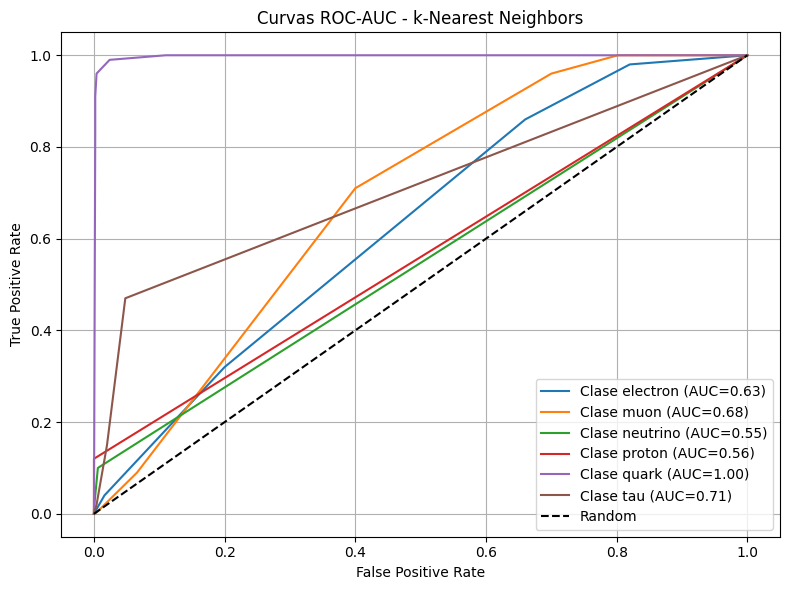

In [ ]:
y_test_bin = label_binarize(y_test, classes=class_names)

# Obtener las probabilidades de predicción de kNN (necesario para ROC)
y_score = pipe_knn.predict_proba(X_test)

fpr = dict()
tpr = dict()
roc_auc = dict()

# Calcular ROC y AUC para cada clase
for i, clase in enumerate(class_names):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

plt.figure(figsize=(8, 6))
# Graficar todas las curvas ROC
for i, clase in enumerate(class_names):
    plt.plot(fpr[i], tpr[i], label=f'Clase {clase} (AUC={roc_auc[i]:.2f})')

# Graficar la línea de referencia
plt.plot([0, 1], [0, 1], 'k--', label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
# Título actualizado
plt.title('Curvas ROC-AUC - k-Nearest Neighbors') 
plt.legend(loc='lower right')
plt.grid(True)
plt.tight_layout()
plt.show()


Evaluación de Overfitting: KNN
Accuracy Train: 0.5492 | Test: 0.3583 | Diff: 0.1908
F1-Score Train: 0.5123 | Test: 0.2809 | Diff: 0.2314
OVERFITTING (diferencia >10%)


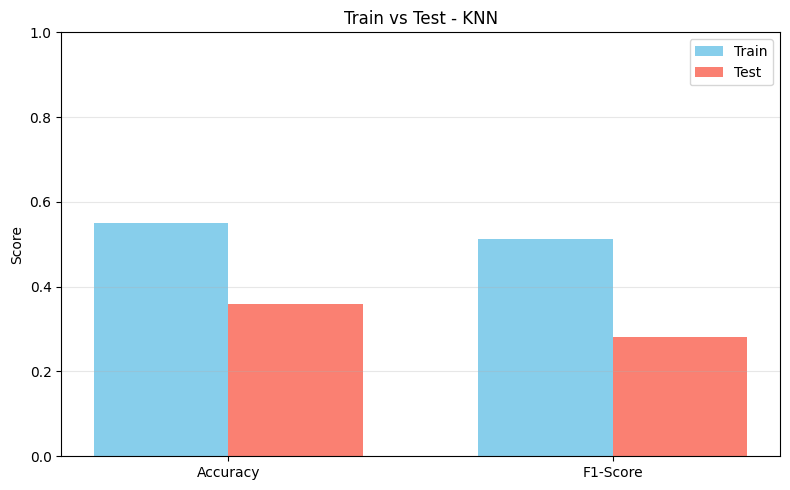

In [ ]:
evaluar_overfitting(pipe_knn, X_train, X_test, y_train, y_test, "KNN")

---
### 4.4 🟧 NAIVE BAYES

#### 4.4.1 Hiperparámetros y Entrenamiento

In [ ]:
NB_PARAMS = {
    'var_smoothing': np.float64(0.0001)
}

# 1. Pipeline y entrenamiento de Naive Bayes (50% varianza)
pipe_nb = Pipeline([
    ('scaler', StandardScaler()),
    ('pca', PCA(n_components=0.50)),
    # Se usa GaussianNB con el parámetro var_smoothing
    ('clf', GaussianNB(**NB_PARAMS)) 
])
pipe_nb.fit(X_train, y_train)

# 2. Validación cruzada (CV) - usa el mismo criterio de 50% de varianza
pipe_nb_cv = Pipeline([
    ('scaler', StandardScaler()),
    ('pca', PCA(n_components=0.50)),
    ('clf', GaussianNB(**NB_PARAMS))
])
cv_scores = cross_val_score(pipe_nb_cv, X_train, y_train, cv=5, scoring='accuracy', n_jobs=-1) 
print(f'Accuracy CV (5 folds): {cv_scores.mean():.4f}')

# 3. Pipelines adicionales para comparación de curvas de aprendizaje (diferentes umbrales de PCA)
pipe_nb_25 = Pipeline([
    ('scaler', StandardScaler()),
    ('pca', PCA(n_components=0.25)),
    ('clf', GaussianNB(**NB_PARAMS))
])

pipe_nb_95 = Pipeline([
    ('scaler', StandardScaler()),
    ('pca', PCA(n_components=0.95)),
    ('clf', GaussianNB(**NB_PARAMS))
])

pipe_nb_99 = Pipeline([
    ('scaler', StandardScaler()),
    ('pca', PCA(n_components=0.99)),
    ('clf', GaussianNB(**NB_PARAMS))
])

Accuracy CV (5 folds): 0.1783


#### 4.4.2 Evaluación y Métricas

In [ ]:
y_pred = pipe_nb.predict(X_test)
y_train_pred = pipe_nb.predict(X_train)

# 2. Cálculo de Accuracy
acc_test = accuracy_score(y_test, y_pred)
acc_train = accuracy_score(y_train, y_train_pred)

# 3. Impresión de Métricas
print(f'Accuracy en train: {acc_train:.4f}')
print(f'Accuracy en test: {acc_test:.4f}')
print(f'Accuracy CV (5 folds): {cv_scores.mean():.4f}') # Usa el resultado de la CV del código anterior
print('\nReporte de clasificación:')

# 4. Reporte de Clasificación
print(classification_report(y_test, y_pred))

Accuracy en train: 0.6579
Accuracy en test: 0.1833
Accuracy CV (5 folds): 0.1783

Reporte de clasificación:
              precision    recall  f1-score   support

    electron       0.27      0.03      0.05       100
        muon       0.00      0.00      0.00       100
    neutrino       0.00      0.00      0.00       100
      proton       1.00      0.02      0.04       100
       quark       0.20      1.00      0.34       100
         tau       0.05      0.05      0.05       100

    accuracy                           0.18       600
   macro avg       0.25      0.18      0.08       600
weighted avg       0.25      0.18      0.08       600



c:\Users\leon9\OneDrive\Desktop\Fisica\Mineria\parcial2\p2\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\leon9\OneDrive\Desktop\Fisica\Mineria\parcial2\p2\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\leon9\OneDrive\Desktop\Fisica\Mineria\parcial2\p2\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _

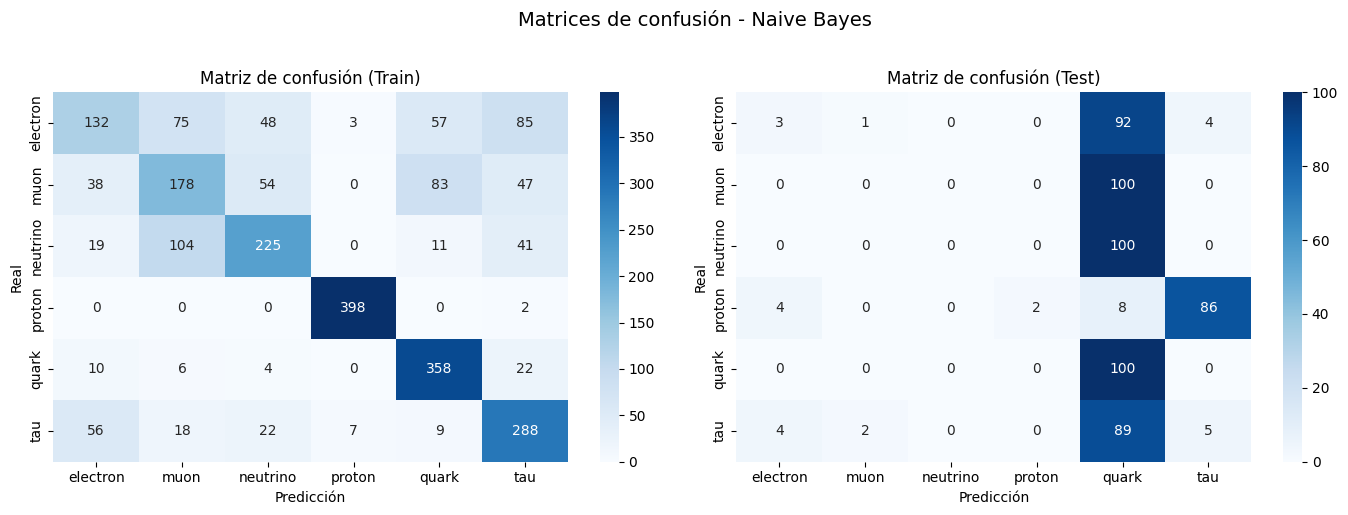

In [ ]:
class_names = sorted(list(set(y))) 

# Matriz de confusión Train y Test
cm_train = confusion_matrix(y_train, y_train_pred, labels=class_names)
cm_test = confusion_matrix(y_test, y_pred, labels=class_names)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.heatmap(cm_train, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_names, yticklabels=class_names, ax=axes[0])
axes[0].set_xlabel('Predicción')
axes[0].set_ylabel('Real')
axes[0].set_title('Matriz de confusión (Train)')

sns.heatmap(cm_test, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_names, yticklabels=class_names, ax=axes[1])
axes[1].set_xlabel('Predicción')
axes[1].set_ylabel('Real')
axes[1].set_title('Matriz de confusión (Test)')
plt.suptitle('Matrices de confusión - Naive Bayes', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

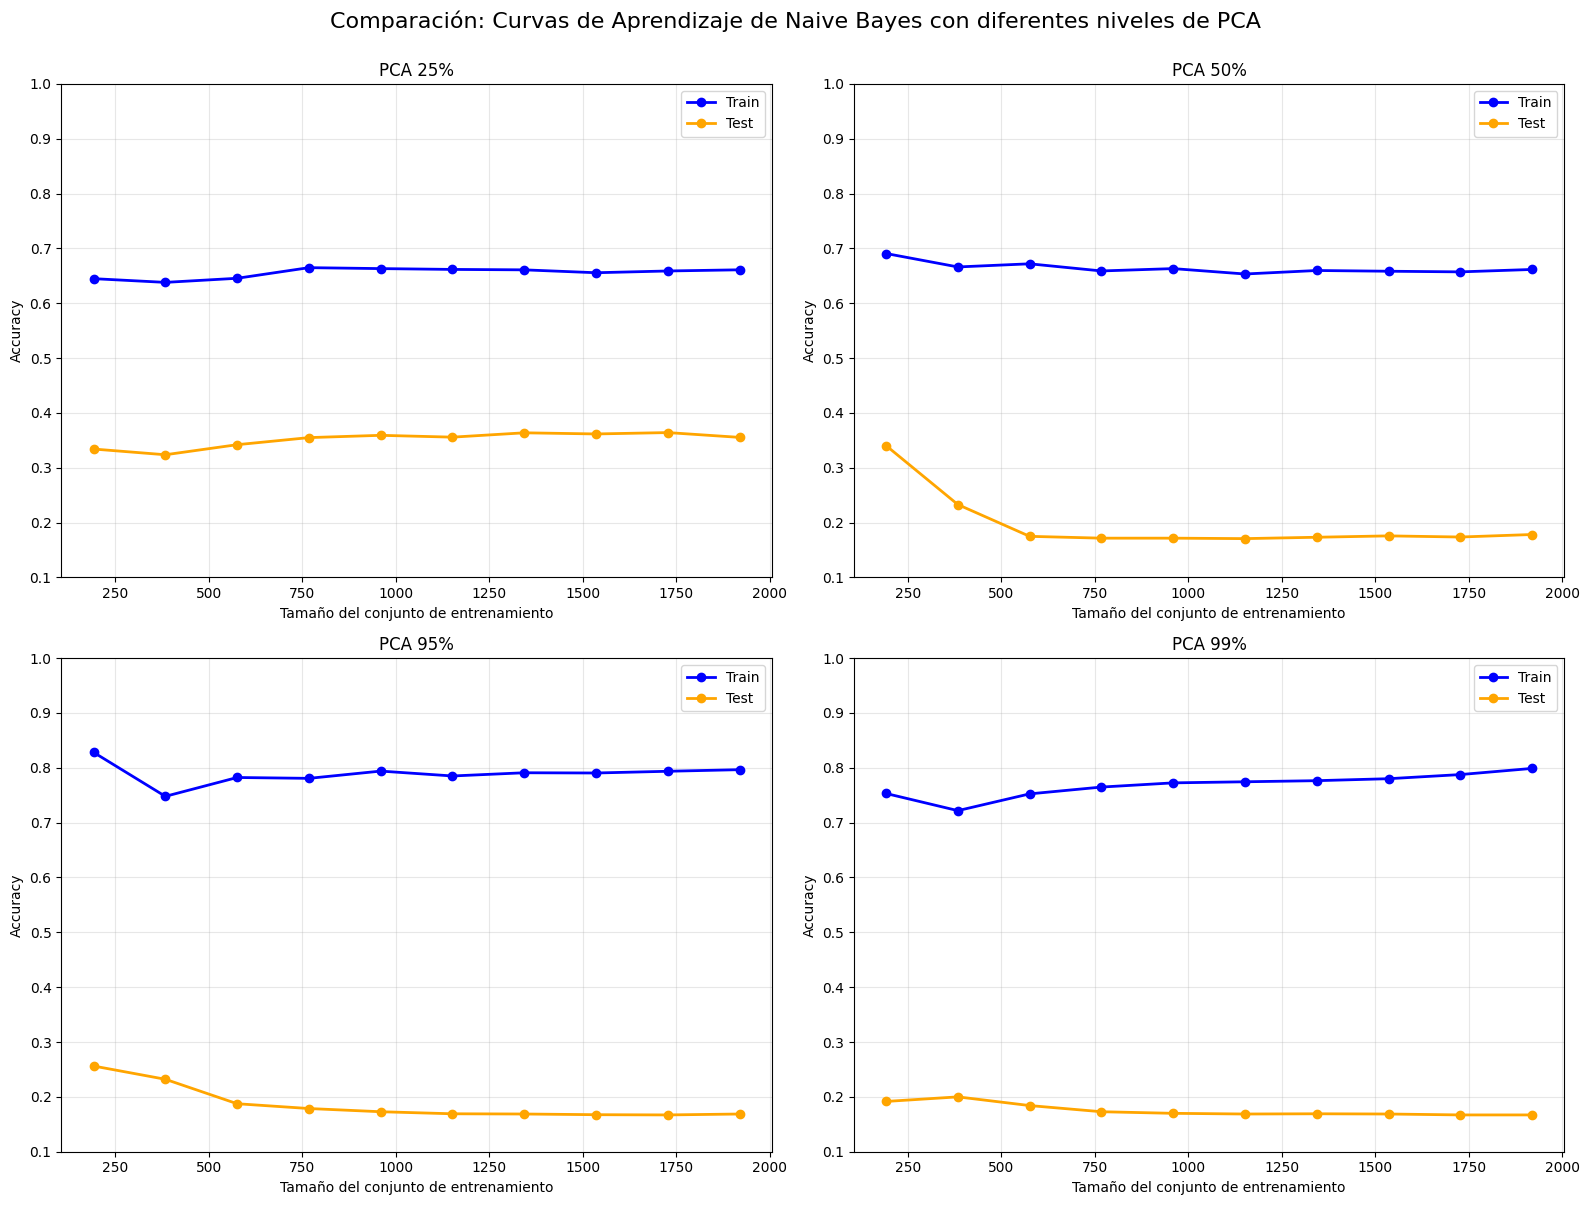

In [ ]:
train_sizes_50, train_scores_50, test_scores_50 = learning_curve(
    pipe_nb_cv, X_train, y_train, cv=5, 
    train_sizes=np.linspace(0.1, 1.0, 10), 
    scoring='accuracy', n_jobs=-1
)

# Calcular curvas con PCA 25%
train_sizes_25, train_scores_25, test_scores_25 = learning_curve(
    pipe_nb_25, X_train, y_train, cv=5, 
    train_sizes=np.linspace(0.1, 1.0, 10), 
    scoring='accuracy', n_jobs=-1
)

# Calcular curvas con PCA 95%
train_sizes_95, train_scores_95, test_scores_95 = learning_curve(
    pipe_nb_95, X_train, y_train, cv=5, 
    train_sizes=np.linspace(0.1, 1.0, 10), 
    scoring='accuracy', n_jobs=-1
)

# Calcular curvas con PCA 99%
train_sizes_99, train_scores_99, test_scores_99 = learning_curve(
    pipe_nb_99, X_train, y_train, cv=5, 
    train_sizes=np.linspace(0.1, 1.0, 10), 
    scoring='accuracy', n_jobs=-1
)

# --- 2. Promediar los scores ---
train_mean_50 = train_scores_50.mean(axis=1)
test_mean_50 = test_scores_50.mean(axis=1)
train_mean_25 = train_scores_25.mean(axis=1)
test_mean_25 = test_scores_25.mean(axis=1)
train_mean_95 = train_scores_95.mean(axis=1)
test_mean_95 = test_scores_95.mean(axis=1)
train_mean_99 = train_scores_99.mean(axis=1)
test_mean_99 = test_scores_99.mean(axis=1)

# --- 3. Gráfico comparativo 2x2 ---
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Subplot 1: PCA 25%
axes[0, 0].plot(train_sizes_25, train_mean_25, 'o-', label='Train', color='blue', linewidth=2)
axes[0, 0].plot(train_sizes_25, test_mean_25, 'o-', label='Test', color='orange', linewidth=2)
axes[0, 0].set_xlabel('Tamaño del conjunto de entrenamiento')
axes[0, 0].set_ylabel('Accuracy')
axes[0, 0].set_title('PCA 25%')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)
axes[0, 0].set_ylim([0.1, 1.0])

# Subplot 2: PCA 50%
axes[0, 1].plot(train_sizes_50, train_mean_50, 'o-', label='Train', color='blue', linewidth=2)
axes[0, 1].plot(train_sizes_50, test_mean_50, 'o-', label='Test', color='orange', linewidth=2)
axes[0, 1].set_xlabel('Tamaño del conjunto de entrenamiento')
axes[0, 1].set_ylabel('Accuracy')
axes[0, 1].set_title('PCA 50%')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)
axes[0, 1].set_ylim([0.1, 1.0])

# Subplot 3: PCA 95%
axes[1, 0].plot(train_sizes_95, train_mean_95, 'o-', label='Train', color='blue', linewidth=2)
axes[1, 0].plot(train_sizes_95, test_mean_95, 'o-', label='Test', color='orange', linewidth=2)
axes[1, 0].set_xlabel('Tamaño del conjunto de entrenamiento')
axes[1, 0].set_ylabel('Accuracy')
axes[1, 0].set_title('PCA 95%')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)
axes[1, 0].set_ylim([0.1, 1.0])

# Subplot 4: PCA 99%
axes[1, 1].plot(train_sizes_99, train_mean_99, 'o-', label='Train', color='blue', linewidth=2)
axes[1, 1].plot(train_sizes_99, test_mean_99, 'o-', label='Test', color='orange', linewidth=2)
axes[1, 1].set_xlabel('Tamaño del conjunto de entrenamiento')
axes[1, 1].set_ylabel('Accuracy')
axes[1, 1].set_title('PCA 99%')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)
axes[1, 1].set_ylim([0.1, 1.0])

# Título actualizado
plt.suptitle('Comparación: Curvas de Aprendizaje de Naive Bayes con diferentes niveles de PCA', fontsize=16, y=1.00)
plt.tight_layout()
plt.show()

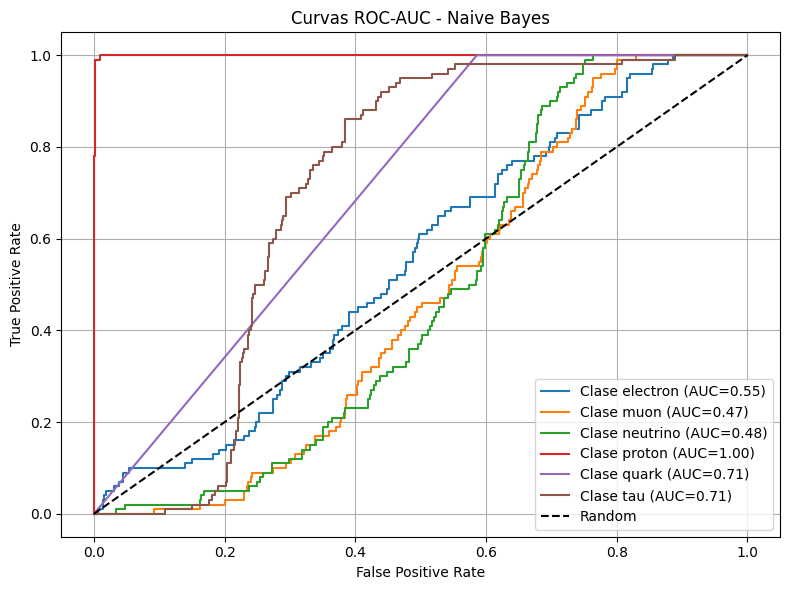

In [ ]:
y_test_bin = label_binarize(y_test, classes=class_names)

y_score = pipe_nb.predict_proba(X_test)

fpr = dict()
tpr = dict()
roc_auc = dict()

for i, clase in enumerate(class_names):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

plt.figure(figsize=(8, 6))
for i, clase in enumerate(class_names):
    plt.plot(fpr[i], tpr[i], label=f'Clase {clase} (AUC={roc_auc[i]:.2f})')

plt.plot([0, 1], [0, 1], 'k--', label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Curvas ROC-AUC - Naive Bayes') 
plt.legend(loc='lower right')
plt.grid(True)
plt.tight_layout()
plt.show()


Evaluación de Overfitting: Naive Bayes
Accuracy Train: 0.6579 | Test: 0.1833 | Diff: 0.4746
F1-Score Train: 0.6454 | Test: 0.0807 | Diff: 0.5647
OVERFITTING (diferencia >10%)


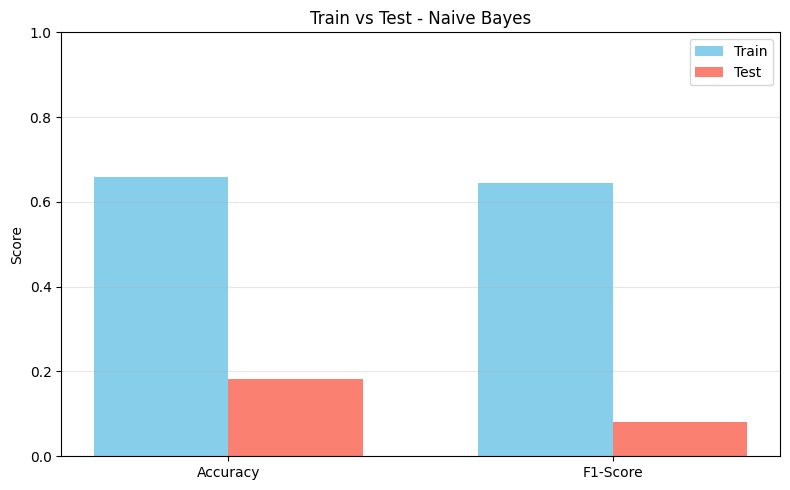

In [ ]:
evaluar_overfitting(pipe_nb, X_train, X_test, y_train, y_test, "Naive Bayes")

---
### 4.5 🟫 ÁRBOL DE DECISIÓN

#### 4.5.1 Hiperparámetros y Entrenamiento

In [ ]:
DT_PARAMS = {
    'criterion': 'entropy',
    'max_depth': 30,
    'min_samples_split': 10,
    'min_samples_leaf': 4,
    'random_state': 42
}

# 1. Pipeline y entrenamiento de Árbol de Decisión (50% varianza)
# Este pipeline se usa para el entrenamiento inicial (pipe_dt.fit)
pipe_dt = Pipeline([
    ('scaler', StandardScaler()),
    ('pca', PCA(n_components=0.50)),
    ('clf', DecisionTreeClassifier(**DT_PARAMS)) 
])
pipe_dt.fit(X_train, y_train)

# 2. Validación cruzada (CV) - usa el mismo criterio de 50% de varianza
# Usamos pipe_dt_cv para calcular el score CV
pipe_dt_cv = Pipeline([
    ('scaler', StandardScaler()),
    ('pca', PCA(n_components=0.50)),
    ('clf', DecisionTreeClassifier(**DT_PARAMS))
])
cv_scores = cross_val_score(pipe_dt_cv, X_train, y_train, cv=5, scoring='accuracy') 
print(f'Accuracy CV (5 folds): {cv_scores.mean():.4f}')

pipe_dt_25 = Pipeline([
    ('scaler', StandardScaler()),
    ('pca', PCA(n_components=0.25)),
    ('clf', DecisionTreeClassifier(**DT_PARAMS))
])

pipe_dt_95 = Pipeline([
    ('scaler', StandardScaler()),
    ('pca', PCA(n_components=0.95)),
    ('clf', DecisionTreeClassifier(**DT_PARAMS))
])

pipe_dt_99 = Pipeline([
    ('scaler', StandardScaler()),
    ('pca', PCA(n_components=0.99)),
    ('clf', DecisionTreeClassifier(**DT_PARAMS))
])

Accuracy CV (5 folds): 0.6171


#### 4.5.2 Evaluación y Métricas

In [ ]:
y_pred = pipe_dt.predict(X_test)
y_train_pred = pipe_dt.predict(X_train)

# 2. Cálculo de Accuracy
acc_test = accuracy_score(y_test, y_pred)
acc_train = accuracy_score(y_train, y_train_pred)

# 3. Impresión de Métricas
print(f'Accuracy en train: {acc_train:.4f}')
print(f'Accuracy en test: {acc_test:.4f}')
print(f'Accuracy CV (5 folds): {cv_scores.mean():.4f}') # Usa el resultado de la CV del código anterior
print('\nReporte de clasificación:')

# 4. Reporte de Clasificación
print(classification_report(y_test, y_pred))

Accuracy en train: 0.9242
Accuracy en test: 0.6067
Accuracy CV (5 folds): 0.6171

Reporte de clasificación:
              precision    recall  f1-score   support

    electron       0.36      0.26      0.30       100
        muon       0.33      0.43      0.37       100
    neutrino       0.44      0.58      0.50       100
      proton       0.99      0.98      0.98       100
       quark       0.98      0.91      0.94       100
         tau       0.66      0.48      0.55       100

    accuracy                           0.61       600
   macro avg       0.63      0.61      0.61       600
weighted avg       0.63      0.61      0.61       600



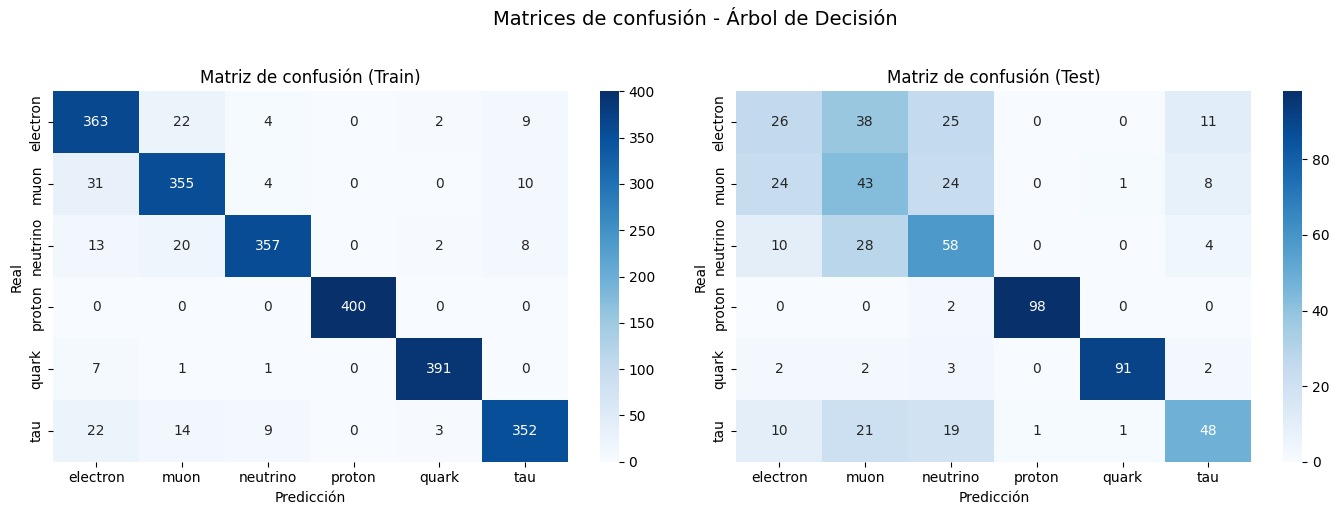

In [ ]:
class_names = sorted(list(set(y))) 

cm_train = confusion_matrix(y_train, y_train_pred, labels=class_names)
cm_test = confusion_matrix(y_test, y_pred, labels=class_names)

# Creamos la figura con dos subgráficos
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Matriz de confusión Train
sns.heatmap(cm_train, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_names, yticklabels=class_names, ax=axes[0])
axes[0].set_xlabel('Predicción')
axes[0].set_ylabel('Real')
axes[0].set_title('Matriz de confusión (Train)')

# 2. Matriz de confusión Test
sns.heatmap(cm_test, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_names, yticklabels=class_names, ax=axes[1])
axes[1].set_xlabel('Predicción')
axes[1].set_ylabel('Real')
axes[1].set_title('Matriz de confusión (Test)')

# Título general
plt.suptitle('Matrices de confusión - Árbol de Decisión', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

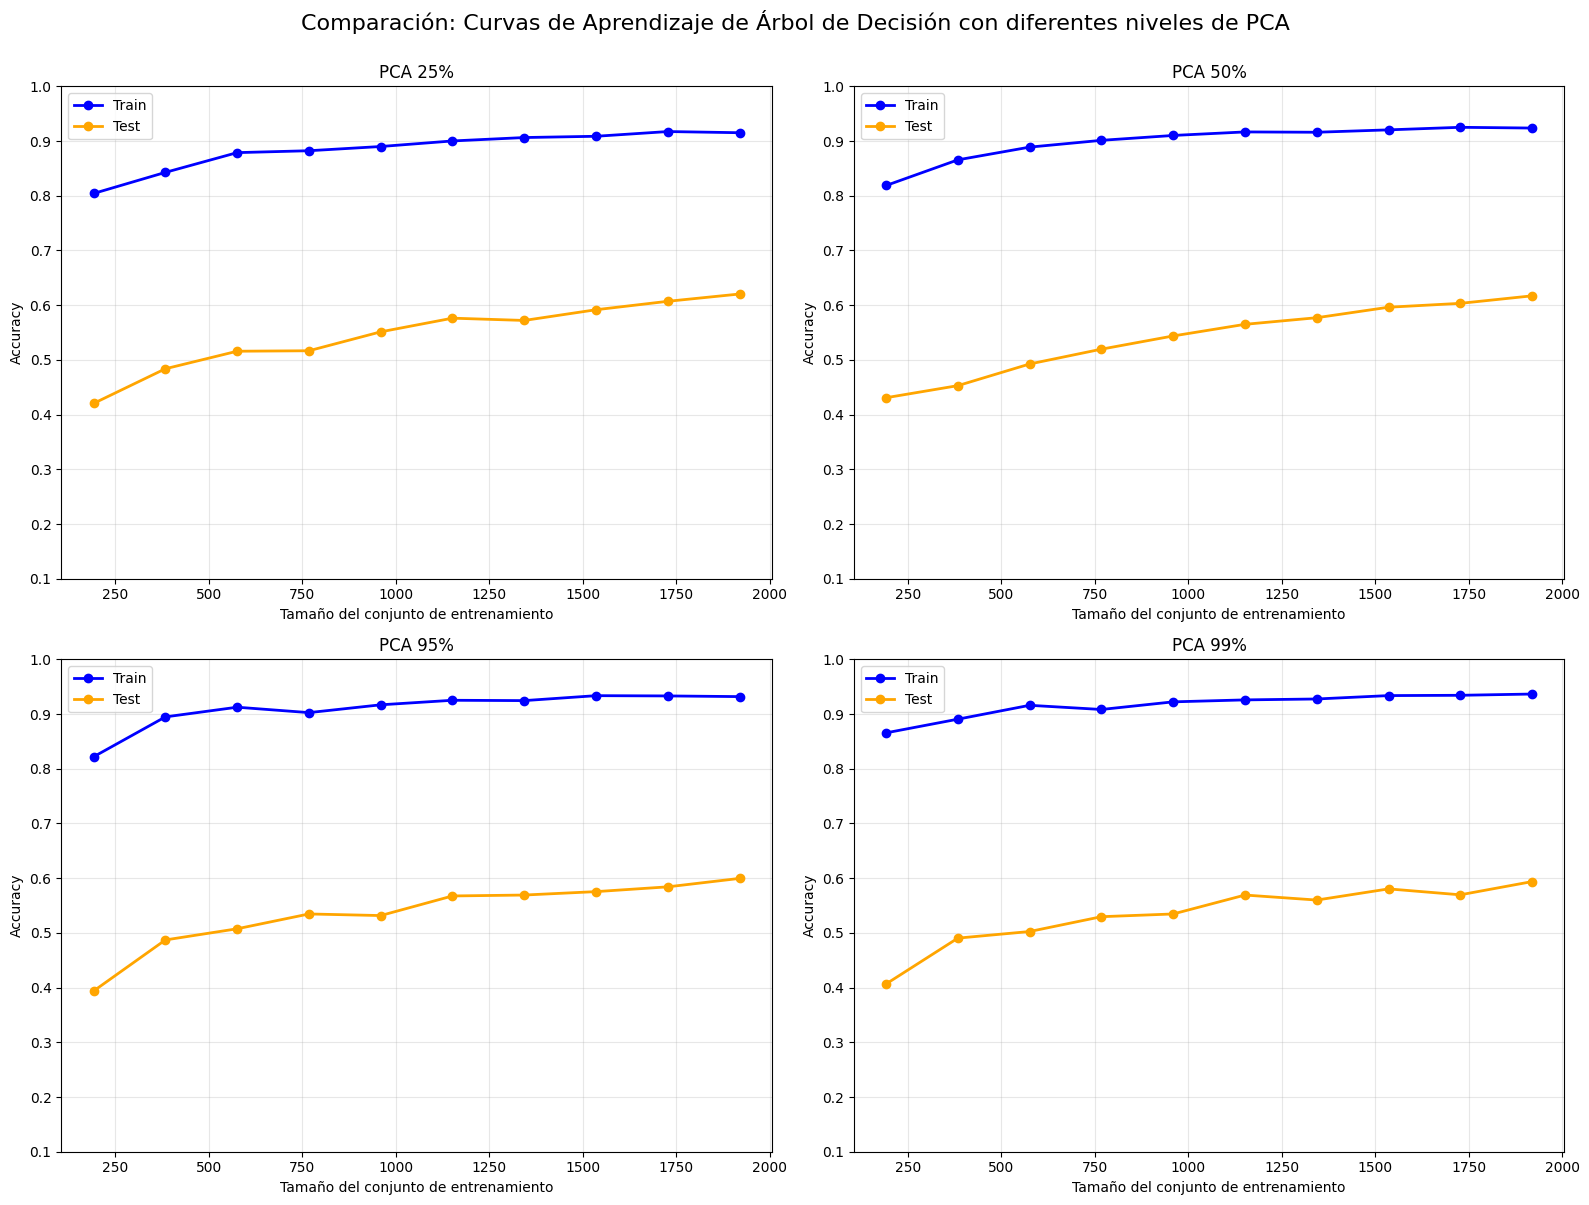

In [ ]:
train_sizes_50, train_scores_50, test_scores_50 = learning_curve(
    pipe_dt_cv, X_train, y_train, cv=5, 
    train_sizes=np.linspace(0.1, 1.0, 10), 
    scoring='accuracy', n_jobs=-1
)

# Calcular curvas con PCA 25%
train_sizes_25, train_scores_25, test_scores_25 = learning_curve(
    pipe_dt_25, X_train, y_train, cv=5, 
    train_sizes=np.linspace(0.1, 1.0, 10), 
    scoring='accuracy', n_jobs=-1
)

# Calcular curvas con PCA 95%
train_sizes_95, train_scores_95, test_scores_95 = learning_curve(
    pipe_dt_95, X_train, y_train, cv=5, 
    train_sizes=np.linspace(0.1, 1.0, 10), 
    scoring='accuracy', n_jobs=-1
)

# Calcular curvas con PCA 99%
train_sizes_99, train_scores_99, test_scores_99 = learning_curve(
    pipe_dt_99, X_train, y_train, cv=5, 
    train_sizes=np.linspace(0.1, 1.0, 10), 
    scoring='accuracy', n_jobs=-1
)

# --- 2. Promediar los scores ---
train_mean_50 = train_scores_50.mean(axis=1)
test_mean_50 = test_scores_50.mean(axis=1)
train_mean_25 = train_scores_25.mean(axis=1)
test_mean_25 = test_scores_25.mean(axis=1)
train_mean_95 = train_scores_95.mean(axis=1)
test_mean_95 = test_scores_95.mean(axis=1)
train_mean_99 = train_scores_99.mean(axis=1)
test_mean_99 = test_scores_99.mean(axis=1)

# --- 3. Gráfico comparativo 2x2 ---
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Subplot 1: PCA 25%
axes[0, 0].plot(train_sizes_25, train_mean_25, 'o-', label='Train', color='blue', linewidth=2)
axes[0, 0].plot(train_sizes_25, test_mean_25, 'o-', label='Test', color='orange', linewidth=2)
axes[0, 0].set_xlabel('Tamaño del conjunto de entrenamiento')
axes[0, 0].set_ylabel('Accuracy')
axes[0, 0].set_title('PCA 25%')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)
axes[0, 0].set_ylim([0.1, 1.0])

# Subplot 2: PCA 50%
axes[0, 1].plot(train_sizes_50, train_mean_50, 'o-', label='Train', color='blue', linewidth=2)
axes[0, 1].plot(train_sizes_50, test_mean_50, 'o-', label='Test', color='orange', linewidth=2)
axes[0, 1].set_xlabel('Tamaño del conjunto de entrenamiento')
axes[0, 1].set_ylabel('Accuracy')
axes[0, 1].set_title('PCA 50%')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)
axes[0, 1].set_ylim([0.1, 1.0])

# Subplot 3: PCA 95%
axes[1, 0].plot(train_sizes_95, train_mean_95, 'o-', label='Train', color='blue', linewidth=2)
axes[1, 0].plot(train_sizes_95, test_mean_95, 'o-', label='Test', color='orange', linewidth=2)
axes[1, 0].set_xlabel('Tamaño del conjunto de entrenamiento')
axes[1, 0].set_ylabel('Accuracy')
axes[1, 0].set_title('PCA 95%')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)
axes[1, 0].set_ylim([0.1, 1.0])

# Subplot 4: PCA 99%
axes[1, 1].plot(train_sizes_99, train_mean_99, 'o-', label='Train', color='blue', linewidth=2)
axes[1, 1].plot(train_sizes_99, test_mean_99, 'o-', label='Test', color='orange', linewidth=2)
axes[1, 1].set_xlabel('Tamaño del conjunto de entrenamiento')
axes[1, 1].set_ylabel('Accuracy')
axes[1, 1].set_title('PCA 99%')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)
axes[1, 1].set_ylim([0.1, 1.0])

plt.suptitle('Comparación: Curvas de Aprendizaje de Árbol de Decisión con diferentes niveles de PCA', fontsize=16, y=1.00)
plt.tight_layout()
plt.show()

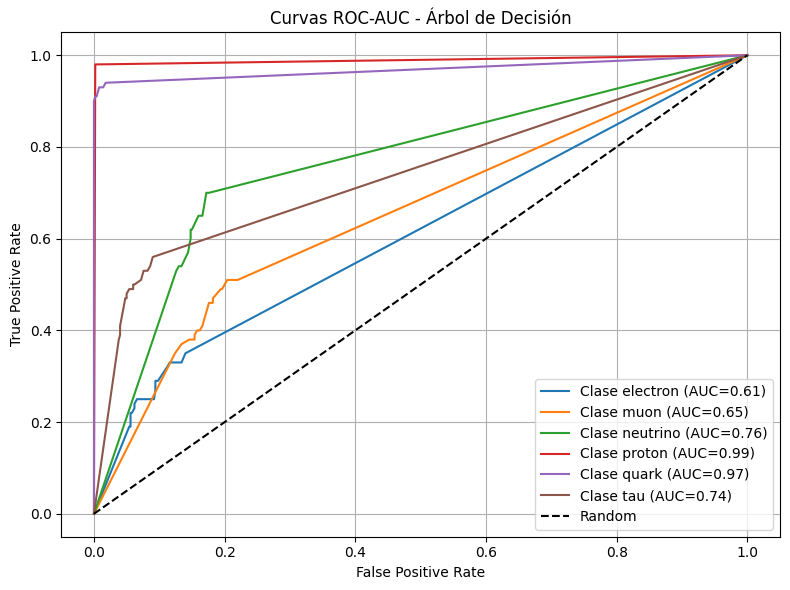

In [ ]:
y_test_bin = label_binarize(y_test, classes=class_names)

y_score = pipe_dt.predict_proba(X_test)

fpr = dict()
tpr = dict()
roc_auc = dict()

# Calcular ROC y AUC para cada clase
for i, clase in enumerate(class_names):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

plt.figure(figsize=(8, 6))
# Graficar todas las curvas ROC
for i, clase in enumerate(class_names):
    plt.plot(fpr[i], tpr[i], label=f'Clase {clase} (AUC={roc_auc[i]:.2f})')

# Graficar la línea de referencia
plt.plot([0, 1], [0, 1], 'k--', label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
# Título actualizado
plt.title('Curvas ROC-AUC - Árbol de Decisión') 
plt.legend(loc='lower right')
plt.grid(True)
plt.tight_layout()
plt.show()


Evaluación de Overfitting: Árbol de Decisión
Accuracy Train: 0.9242 | Test: 0.6067 | Diff: 0.3175
F1-Score Train: 0.9246 | Test: 0.6097 | Diff: 0.3150
OVERFITTING (diferencia >10%)


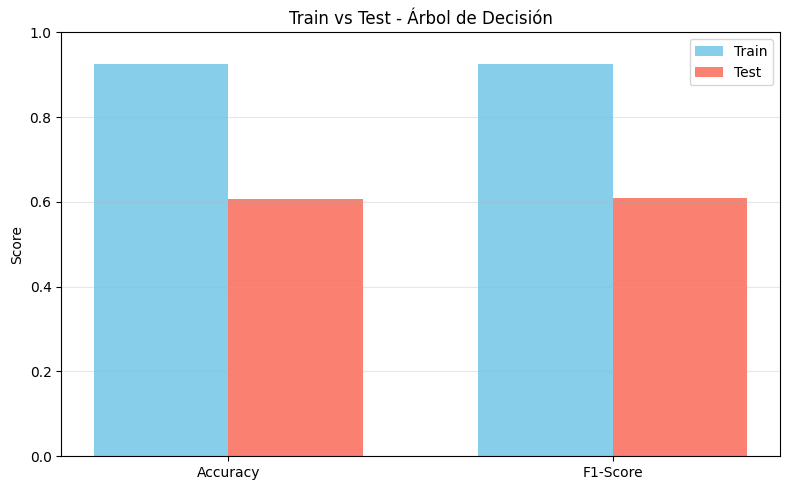

In [ ]:
evaluar_overfitting(pipe_dt, X_train, X_test, y_train, y_test, "Árbol de Decisión")

# Ensambles

### Hiperparametros clasificadores anteriores

In [ ]:
LR_PARAMS = {'C': logreg_C, 'penalty': logreg_penalty,'solver': logreg_solver, 'max_iter': 1000, 'random_state': 42}
DT_PARAMS = {'max_depth': 30, 'min_samples_split': 10, 'min_samples_leaf': 4, 'random_state': 42}
KNN_PARAMS = {'n_neighbors': 5, 'weights': 'uniform', 'metric': 'euclidean'}
NB_PARAMS = {} # GaussianNB no suele tener muchos hiperparámetros.

---
### 4.6 🌳 RANDOM FOREST

#### 4.6.1 Hiperparámetros y Entrenamiento

In [ ]:
RF_PARAMS = {
    'n_estimators': 100,
    'min_samples_split': 10,
    'min_samples_leaf': 2,
    'max_depth': None, 
    'random_state': 42
}

pipe_rf = Pipeline([
    ('scaler', StandardScaler()),
    ('pca', PCA(n_components=0.50)),
    ('clf', RandomForestClassifier(**RF_PARAMS)) 
])
pipe_rf.fit(X_train, y_train)

pipe_rf_cv = Pipeline([
    ('scaler', StandardScaler()),
    ('pca', PCA(n_components=0.50)),
    ('clf', RandomForestClassifier(**RF_PARAMS))
])
cv_scores_50 = cross_val_score(pipe_rf_cv, X_train, y_train, cv=5, scoring='accuracy', n_jobs=-1) 
print(f'Accuracy RF CV (5 folds, PCA 50%): {cv_scores_50.mean():.4f}')

pipe_rf_25 = Pipeline([
    ('scaler', StandardScaler()),
    ('pca', PCA(n_components=0.25)),
    ('clf', RandomForestClassifier(**RF_PARAMS))
])

pipe_rf_95 = Pipeline([
    ('scaler', StandardScaler()),
    ('pca', PCA(n_components=0.95)),
    ('clf', RandomForestClassifier(**RF_PARAMS))
])

pipe_rf_99 = Pipeline([
    ('scaler', StandardScaler()),
    ('pca', PCA(n_components=0.99)),
    ('clf', RandomForestClassifier(**RF_PARAMS))
])

Accuracy RF CV (5 folds, PCA 50%): 0.6587


#### 4.6.2 Evaluación y Métricas

In [ ]:
y_pred = pipe_rf.predict(X_test)
y_train_pred = pipe_rf.predict(X_train)

# 2. Cálculo de Accuracy
acc_test = accuracy_score(y_test, y_pred)
acc_train = accuracy_score(y_train, y_train_pred)

# 3. Impresión de Métricas
print(f'Accuracy en train: {acc_train:.4f}')
print(f'Accuracy en test: {acc_test:.4f}')
print(f'Accuracy CV (5 folds): {cv_scores.mean():.4f}') 
print('\nReporte de clasificación:')

# 4. Reporte de Clasificación
print(classification_report(y_test, y_pred))

Accuracy en train: 1.0000
Accuracy en test: 0.6867
Accuracy CV (5 folds): 0.6958

Reporte de clasificación:
              precision    recall  f1-score   support

    electron       0.58      0.07      0.12       100
        muon       0.42      0.66      0.52       100
    neutrino       0.54      0.79      0.64       100
      proton       1.00      1.00      1.00       100
       quark       0.97      0.97      0.97       100
         tau       0.72      0.63      0.67       100

    accuracy                           0.69       600
   macro avg       0.71      0.69      0.65       600
weighted avg       0.71      0.69      0.65       600



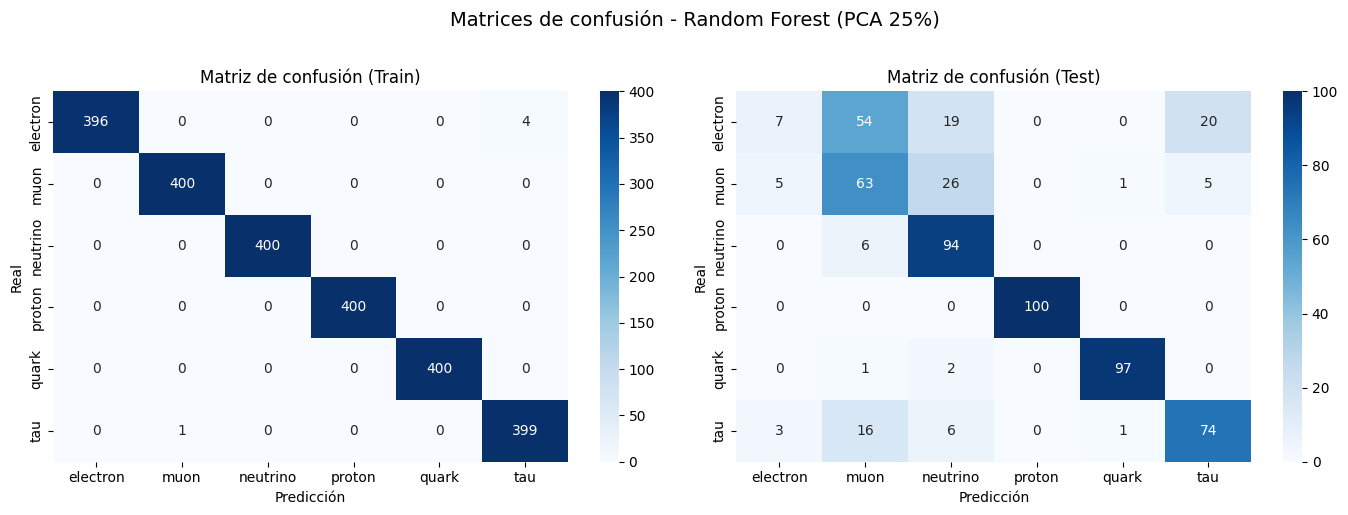

In [ ]:
class_names = sorted(list(set(y))) 

# Matriz de confusión Train y Test
cm_train = confusion_matrix(y_train, y_train_pred, labels=class_names)
cm_test = confusion_matrix(y_test, y_pred, labels=class_names)

# Creamos la figura con dos subgráficos
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Matriz de confusión Train
sns.heatmap(cm_train, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_names, yticklabels=class_names, ax=axes[0])
axes[0].set_xlabel('Predicción')
axes[0].set_ylabel('Real')
axes[0].set_title('Matriz de confusión (Train)')

# 2. Matriz de confusión Test
sns.heatmap(cm_test, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_names, yticklabels=class_names, ax=axes[1])
axes[1].set_xlabel('Predicción')
axes[1].set_ylabel('Real')
axes[1].set_title('Matriz de confusión (Test)')

# Título general actualizado
plt.suptitle('Matrices de confusión - Random Forest (PCA 25%)', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

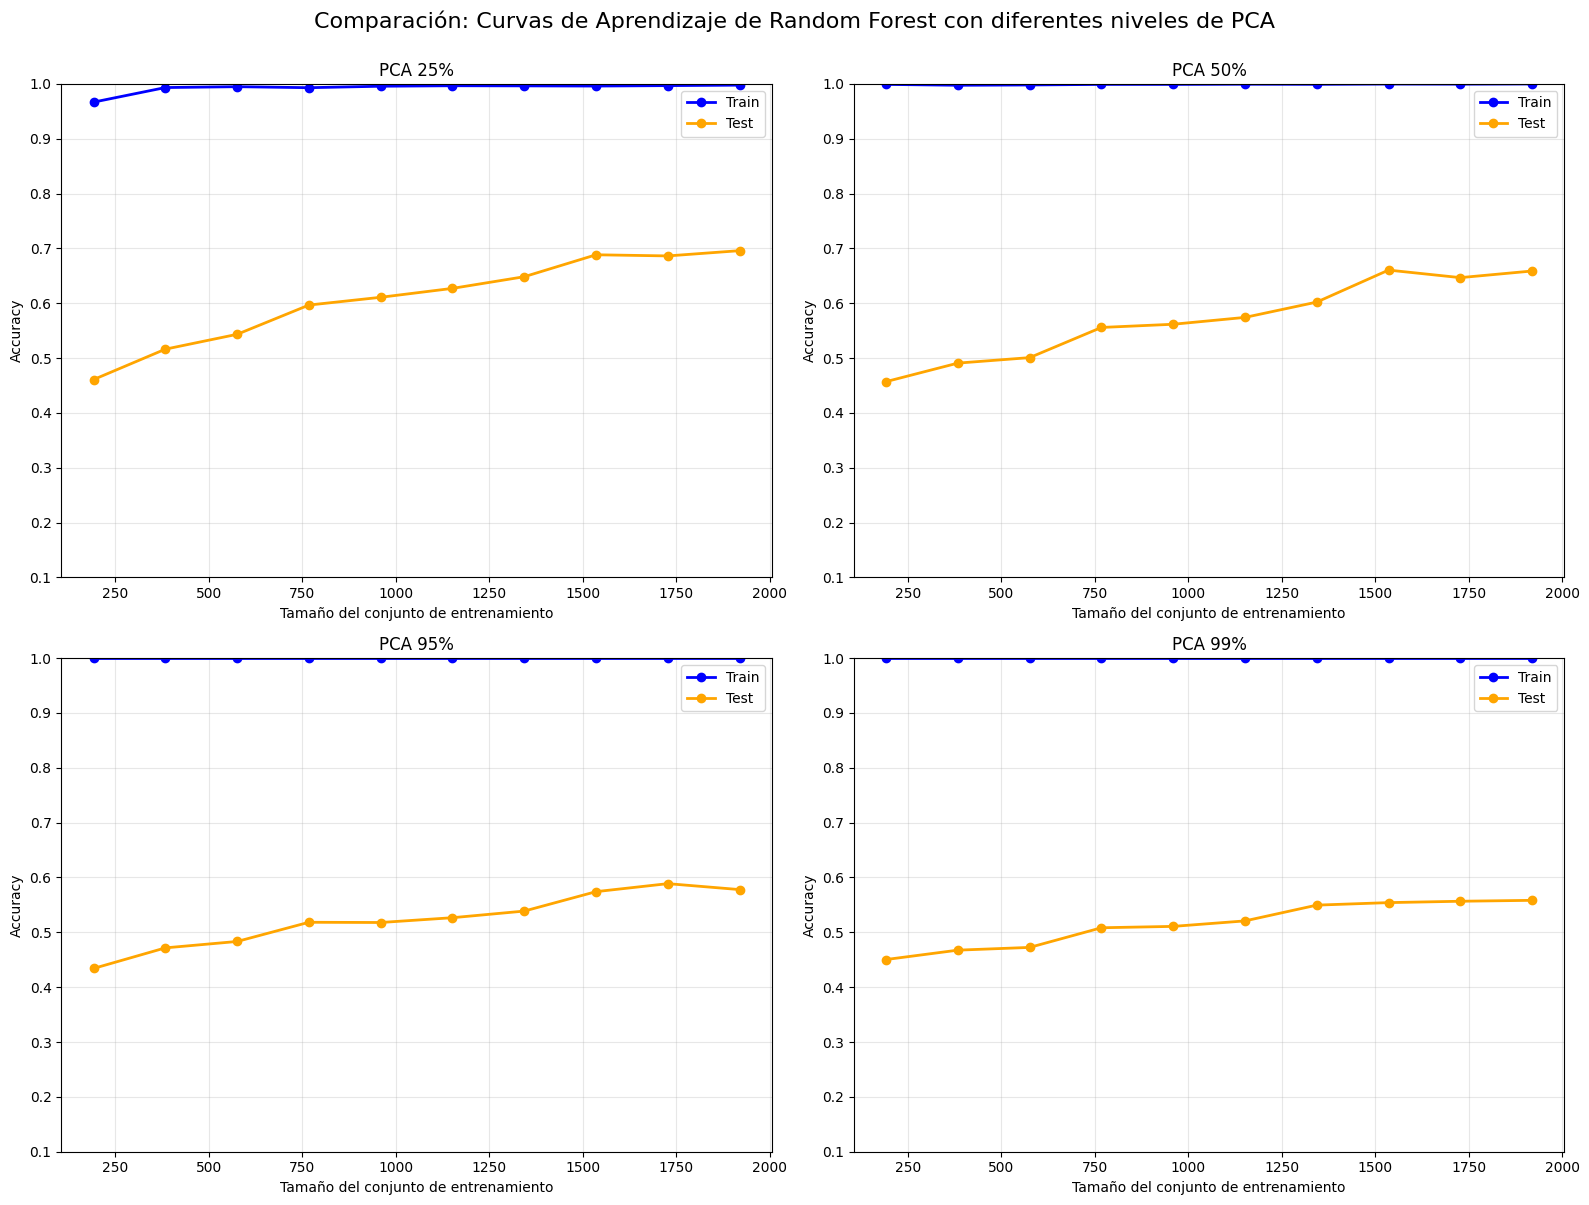

In [ ]:
train_sizes_50, train_scores_50, test_scores_50 = learning_curve(
    pipe_rf_cv, X_train, y_train, cv=5, 
    train_sizes=np.linspace(0.1, 1.0, 10), 
    scoring='accuracy', n_jobs=-1
)

# Calcular curvas con PCA 25%
train_sizes_25, train_scores_25, test_scores_25 = learning_curve(
    pipe_rf_25, X_train, y_train, cv=5, 
    train_sizes=np.linspace(0.1, 1.0, 10), 
    scoring='accuracy', n_jobs=-1
)

# Calcular curvas con PCA 95%
train_sizes_95, train_scores_95, test_scores_95 = learning_curve(
    pipe_rf_95, X_train, y_train, cv=5, 
    train_sizes=np.linspace(0.1, 1.0, 10), 
    scoring='accuracy', n_jobs=-1
)

# Calcular curvas con PCA 99%
train_sizes_99, train_scores_99, test_scores_99 = learning_curve(
    pipe_rf_99, X_train, y_train, cv=5, 
    train_sizes=np.linspace(0.1, 1.0, 10), 
    scoring='accuracy', n_jobs=-1
)

# --- 2. Promediar los scores ---
train_mean_50 = train_scores_50.mean(axis=1)
test_mean_50 = test_scores_50.mean(axis=1)
train_mean_25 = train_scores_25.mean(axis=1)
test_mean_25 = test_scores_25.mean(axis=1)
train_mean_95 = train_scores_95.mean(axis=1)
test_mean_95 = test_scores_95.mean(axis=1)
train_mean_99 = train_scores_99.mean(axis=1)
test_mean_99 = test_scores_99.mean(axis=1)

# --- 3. Gráfico comparativo 2x2 ---
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Subplot 1: PCA 25%
axes[0, 0].plot(train_sizes_25, train_mean_25, 'o-', label='Train', color='blue', linewidth=2)
axes[0, 0].plot(train_sizes_25, test_mean_25, 'o-', label='Test', color='orange', linewidth=2)
axes[0, 0].set_xlabel('Tamaño del conjunto de entrenamiento')
axes[0, 0].set_ylabel('Accuracy')
axes[0, 0].set_title('PCA 25%')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)
axes[0, 0].set_ylim([0.1, 1.0])

# Subplot 2: PCA 50%
axes[0, 1].plot(train_sizes_50, train_mean_50, 'o-', label='Train', color='blue', linewidth=2)
axes[0, 1].plot(train_sizes_50, test_mean_50, 'o-', label='Test', color='orange', linewidth=2)
axes[0, 1].set_xlabel('Tamaño del conjunto de entrenamiento')
axes[0, 1].set_ylabel('Accuracy')
axes[0, 1].set_title('PCA 50%')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)
axes[0, 1].set_ylim([0.1, 1.0])

# Subplot 3: PCA 95%
axes[1, 0].plot(train_sizes_95, train_mean_95, 'o-', label='Train', color='blue', linewidth=2)
axes[1, 0].plot(train_sizes_95, test_mean_95, 'o-', label='Test', color='orange', linewidth=2)
axes[1, 0].set_xlabel('Tamaño del conjunto de entrenamiento')
axes[1, 0].set_ylabel('Accuracy')
axes[1, 0].set_title('PCA 95%')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)
axes[1, 0].set_ylim([0.1, 1.0])

# Subplot 4: PCA 99%
axes[1, 1].plot(train_sizes_99, train_mean_99, 'o-', label='Train', color='blue', linewidth=2)
axes[1, 1].plot(train_sizes_99, test_mean_99, 'o-', label='Test', color='orange', linewidth=2)
axes[1, 1].set_xlabel('Tamaño del conjunto de entrenamiento')
axes[1, 1].set_ylabel('Accuracy')
axes[1, 1].set_title('PCA 99%')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)
axes[1, 1].set_ylim([0.1, 1.0])

# Título actualizado
plt.suptitle('Comparación: Curvas de Aprendizaje de Random Forest con diferentes niveles de PCA', fontsize=16, y=1.00)
plt.tight_layout()
plt.show()

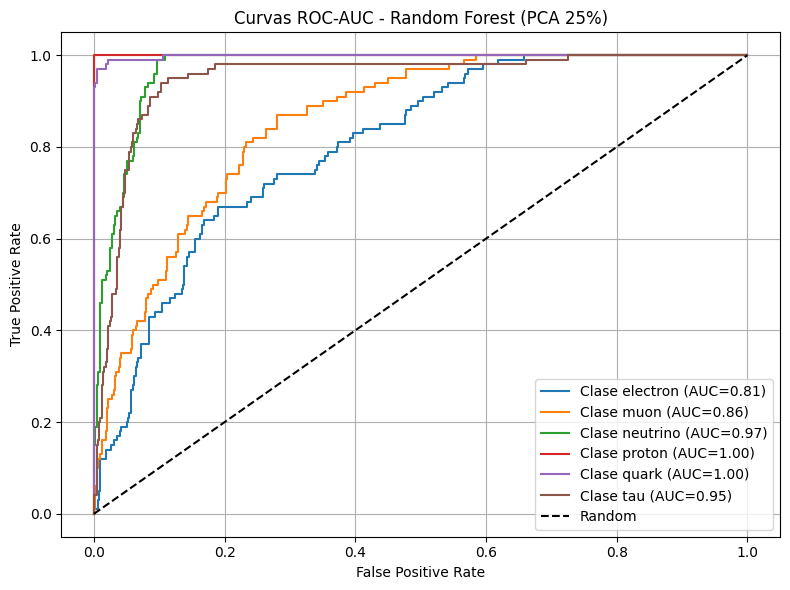

In [ ]:
y_test_bin = label_binarize(y_test, classes=class_names)

# Obtener las probabilidades de predicción de Random Forest (necesario para ROC)
y_score = pipe_rf.predict_proba(X_test)

fpr = dict()
tpr = dict()
roc_auc = dict()

# Calcular ROC y AUC para cada clase
for i, clase in enumerate(class_names):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

plt.figure(figsize=(8, 6))
# Graficar todas las curvas ROC
for i, clase in enumerate(class_names):
    plt.plot(fpr[i], tpr[i], label=f'Clase {clase} (AUC={roc_auc[i]:.2f})')

# Graficar la línea de referencia
plt.plot([0, 1], [0, 1], 'k--', label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
# Título actualizado
plt.title('Curvas ROC-AUC - Random Forest (PCA 25%)') 
plt.legend(loc='lower right')
plt.grid(True)
plt.tight_layout()
plt.show()


Evaluación de Overfitting: Random Forest
Accuracy Train: 0.9979 | Test: 0.7250 | Diff: 0.2729
F1-Score Train: 0.9979 | Test: 0.6877 | Diff: 0.3102
OVERFITTING (diferencia >10%)


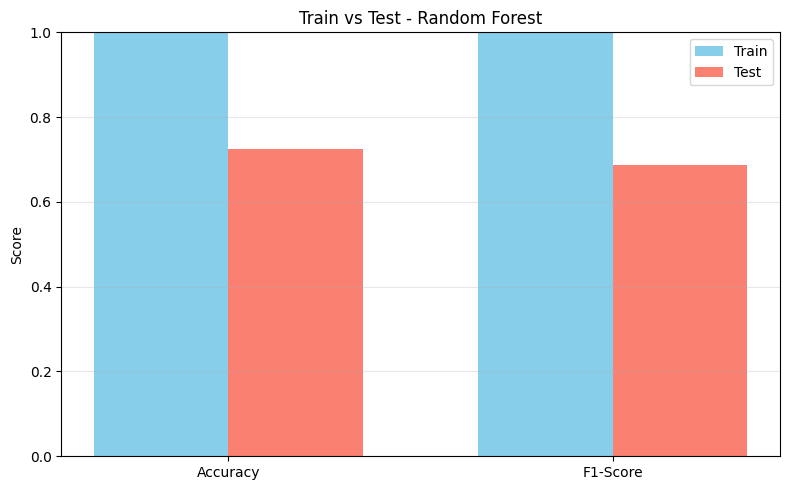

In [ ]:
evaluar_overfitting(pipe_rf, X_train, X_test, y_train, y_test, "Random Forest")

#### 4.6.3 Importancia de características

---
### 4.7 🚀 GRADIENT BOOSTING (Opcional)

#### 4.7.1 Entrenamiento

In [ ]:
GB_PARAMS = {
    'n_estimators': 100,      
    'learning_rate': 0.1,     
    'max_depth': 3,           
    'min_samples_split': 10,
    'min_samples_leaf': 2,
    'random_state': 42
}

# --- 1. Pipeline Principal y Entrenamiento (PCA 50%) ---
# Definimos y entrenamos el pipeline principal (pipe_gb) con PCA 50%
pipe_gb = Pipeline([
    ('scaler', StandardScaler()),
    ('pca', PCA(n_components=0.50)),
    ('clf', GradientBoostingClassifier(**GB_PARAMS)) 
])
pipe_gb.fit(X_train, y_train)

# --- 2. Validación Cruzada (CV) - PCA 50% ---
# Usamos pipe_gb_cv para calcular el score CV
pipe_gb_cv = Pipeline([
    ('scaler', StandardScaler()),
    ('pca', PCA(n_components=0.50)),
    ('clf', GradientBoostingClassifier(**GB_PARAMS))
])
cv_scores_50 = cross_val_score(pipe_gb_cv, X_train, y_train, cv=5, scoring='accuracy', n_jobs=-1) 
print(f'Accuracy GBM CV (5 folds, PCA 50%): {cv_scores_50.mean():.4f}')

# --- 3. Pipelines adicionales para comparación de Curvas de Aprendizaje (diferentes umbrales de PCA) ---

pipe_gb_25 = Pipeline([
    ('scaler', StandardScaler()),
    ('pca', PCA(n_components=0.25)),
    ('clf', GradientBoostingClassifier(**GB_PARAMS))
])

pipe_gb_95 = Pipeline([
    ('scaler', StandardScaler()),
    ('pca', PCA(n_components=0.95)),
    ('clf', GradientBoostingClassifier(**GB_PARAMS))
])

pipe_gb_99 = Pipeline([
    ('scaler', StandardScaler()),
    ('pca', PCA(n_components=0.99)),
    ('clf', GradientBoostingClassifier(**GB_PARAMS))
])

Accuracy GBM CV (5 folds, PCA 50%): 0.6542


In [14]:
y_pred = pipe_gb.predict(X_test)
y_train_pred = pipe_gb.predict(X_train)

# 2. Cálculo de Accuracy
acc_test = accuracy_score(y_test, y_pred)
acc_train = accuracy_score(y_train, y_train_pred)

# 3. Impresión de Métricas
print(f'Accuracy en train: {acc_train:.4f}')
print(f'Accuracy en test: {acc_test:.4f}')
# Usamos el score CV específico para Gradient Boosting
print(f'Accuracy CV (5 folds): {cv_scores_50.mean():.4f}') 
print('\nReporte de clasificación:')

# 4. Reporte de Clasificación
print(classification_report(y_test, y_pred))

Accuracy en train: 0.9950
Accuracy en test: 0.6600
Accuracy CV (5 folds): 0.6542

Reporte de clasificación:
              precision    recall  f1-score   support

    electron       0.34      0.20      0.25       100
        muon       0.41      0.43      0.42       100
    neutrino       0.54      0.88      0.67       100
      proton       1.00      0.97      0.98       100
       quark       1.00      0.96      0.98       100
         tau       0.64      0.52      0.57       100

    accuracy                           0.66       600
   macro avg       0.66      0.66      0.65       600
weighted avg       0.66      0.66      0.65       600



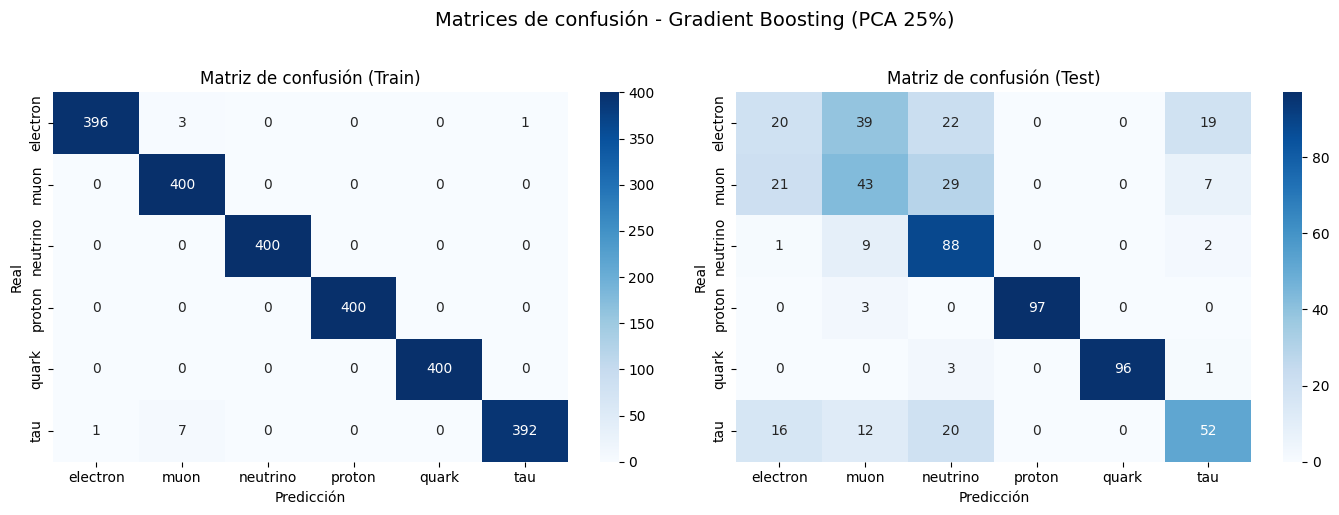

In [15]:
class_names = sorted(list(set(y))) 

# Usamos las predicciones del Gradient Boosting (y_train_pred, y_pred)
cm_train = confusion_matrix(y_train, y_train_pred, labels=class_names)
cm_test = confusion_matrix(y_test, y_pred, labels=class_names)

# Creamos la figura con dos subgráficos
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Matriz de confusión Train
sns.heatmap(cm_train, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_names, yticklabels=class_names, ax=axes[0])
axes[0].set_xlabel('Predicción')
axes[0].set_ylabel('Real')
axes[0].set_title('Matriz de confusión (Train)')

# 2. Matriz de confusión Test
sns.heatmap(cm_test, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_names, yticklabels=class_names, ax=axes[1])
axes[1].set_xlabel('Predicción')
axes[1].set_ylabel('Real')
axes[1].set_title('Matriz de confusión (Test)')

# Título general actualizado para Gradient Boosting
plt.suptitle('Matrices de confusión - Gradient Boosting (PCA 25%)', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

Iniciando cálculo de Curva de Aprendizaje para Gradient Boosting (PCA 25%)...


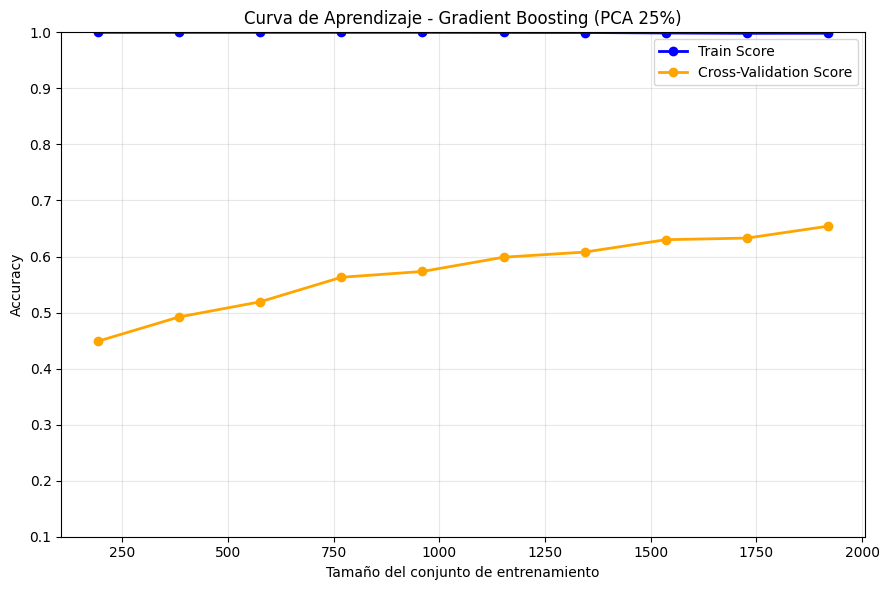

In [19]:
print("Iniciando cálculo de Curva de Aprendizaje para Gradient Boosting (PCA 25%)...")

# Usamos pipe_gb_25 (o el nombre de tu pipeline de GBM con PCA 25%)
train_sizes_25, train_scores_25, test_scores_25 = learning_curve(
    pipe_gb, X_train, y_train, cv=5, 
    train_sizes=np.linspace(0.1, 1.0, 10), 
    scoring='accuracy', 
    n_jobs=-1
)

# --- 2. Promediar los scores ---
train_mean_25 = train_scores_25.mean(axis=1)
test_mean_25 = test_scores_25.mean(axis=1)

# --- 3. Gráfico de Curva de Aprendizaje ---
plt.figure(figsize=(9, 6))

plt.plot(train_sizes_25, train_mean_25, 'o-', 
         label='Train Score', color='blue', linewidth=2)
plt.plot(train_sizes_25, test_mean_25, 'o-', 
         label='Cross-Validation Score', color='orange', linewidth=2)

plt.xlabel('Tamaño del conjunto de entrenamiento')
plt.ylabel('Accuracy')
plt.title('Curva de Aprendizaje - Gradient Boosting (PCA 25%)')
plt.legend(loc='best')
plt.grid(True, alpha=0.3)
plt.ylim([0.1, 1.0])

plt.tight_layout()
plt.show()

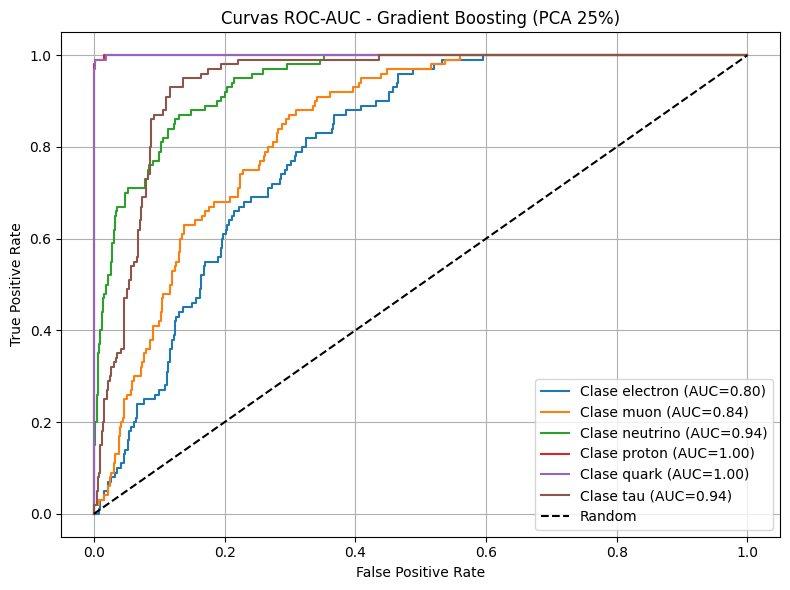

In [18]:
class_names = sorted(list(set(y))) 

# Binarizar las etiquetas de prueba (OVR)
y_test_bin = label_binarize(y_test, classes=class_names)

# Obtener las probabilidades de predicción del Gradient Boosting (necesario para ROC)
# Usamos pipe_gb_25 o el nombre de tu pipeline de GBM con PCA
y_score = pipe_gb.predict_proba(X_test)

fpr = dict()
tpr = dict()
roc_auc = dict()

# Calcular ROC y AUC para cada clase
for i, clase in enumerate(class_names):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

plt.figure(figsize=(8, 6))
# Graficar todas las curvas ROC
for i, clase in enumerate(class_names):
    plt.plot(fpr[i], tpr[i], label=f'Clase {clase} (AUC={roc_auc[i]:.2f})')

# Graficar la línea de referencia
plt.plot([0, 1], [0, 1], 'k--', label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
# Título actualizado
plt.title('Curvas ROC-AUC - Gradient Boosting (PCA 25%)') 
plt.legend(loc='lower right')
plt.grid(True)
plt.tight_layout()
plt.show()

---
### 4.8 🗳️ VOTING CLASSIFIER (Ensamble)

#### 4.8.1 Configuración y Entrenamiento

In [ ]:
# 1. Definir los clasificadores individuales optimizados
clf_lr = LogisticRegression(**LR_PARAMS)
clf_dt = DecisionTreeClassifier(**DT_PARAMS)
clf_knn = KNeighborsClassifier(**KNN_PARAMS)
clf_nb = GaussianNB(**NB_PARAMS)

# 2. Definición del Voting Classifier
voting_clf = VotingClassifier(
    estimators=[
        ('lr', clf_lr),     
        ('dt', clf_dt),     
        ('knn', clf_knn),   
        ('nb', clf_nb)      
    ], 
    voting='soft', 
    n_jobs=-1
)

pipe_voting_25 = Pipeline([
    ('scaler', StandardScaler()),
    ('pca', PCA(n_components=0.25)),
    ('clf', voting_clf)
])

pipe_voting_50 = Pipeline([
    ('scaler', StandardScaler()),
    ('pca', PCA(n_components=0.50)),
    ('clf', voting_clf)
])

pipe_voting_95 = Pipeline([
    ('scaler', StandardScaler()),
    ('pca', PCA(n_components=0.95)),
    ('clf', voting_clf)
])

pipe_voting_99 = Pipeline([
    ('scaler', StandardScaler()),
    ('pca', PCA(n_components=0.99)),
    ('clf', voting_clf)
])
# 3. Entrenamiento y Validación Cruzada
print("Iniciando entrenamiento del Voting Classifier (LR, DT, kNN, NB | PCA 25%)...")
pipe_voting_25.fit(X_train, y_train)

cv_scores_voting_25 = cross_val_score(pipe_voting_25, X_train, y_train, cv=5, scoring='accuracy', n_jobs=-1) 
print('---')
print(f'Accuracy Voting Classifier CV (5 folds, PCA 50%): {cv_scores_voting_25.mean():.4f}')

Iniciando entrenamiento del Voting Classifier (LR, DT, kNN, NB | PCA 25%)...
---
Accuracy Voting Classifier CV (5 folds, PCA 50%): 0.6375


#### 4.8.2 Evaluación y Métricas

In [ ]:
y_pred = pipe_voting_25.predict(X_test)
y_train_pred = pipe_voting_25.predict(X_train)

# 2. Cálculo de Accuracy
acc_test = accuracy_score(y_test, y_pred)
acc_train = accuracy_score(y_train, y_train_pred)

# 3. Impresión de Métricas
print(f'Accuracy en train: {acc_train:.4f}')
print(f'Accuracy en test: {acc_test:.4f}')
print(f'Accuracy CV (5 folds): {cv_scores_voting_25.mean():.4f}') 
print('\nReporte de clasificación:')

# 4. Reporte de Clasificación
print(classification_report(y_test, y_pred))

Accuracy en train: 0.8892
Accuracy en test: 0.6583
Accuracy CV (5 folds): 0.6375

Reporte de clasificación:
              precision    recall  f1-score   support

    electron       0.36      0.18      0.24       100
        muon       0.38      0.75      0.50       100
    neutrino       0.66      0.52      0.58       100
      proton       0.99      1.00      1.00       100
       quark       1.00      0.99      0.99       100
         tau       0.71      0.51      0.59       100

    accuracy                           0.66       600
   macro avg       0.68      0.66      0.65       600
weighted avg       0.68      0.66      0.65       600



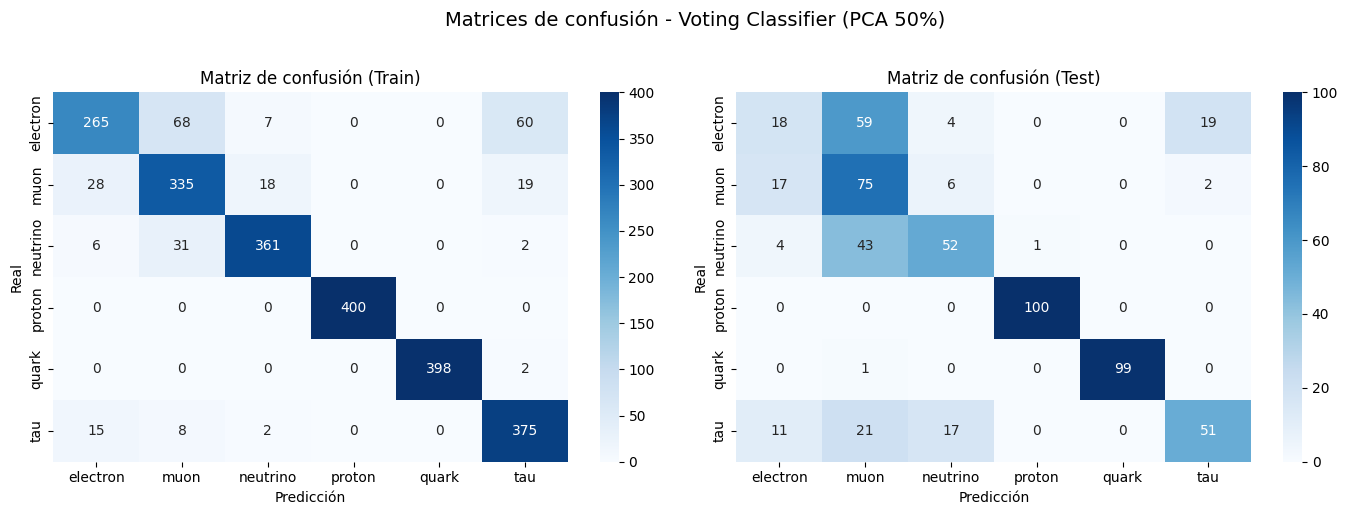

In [ ]:
# Aseguramos que class_names esté definido (obtenido de 'y')
class_names = sorted(list(set(y))) 

# Matriz de confusión Train y Test
# Usamos las predicciones del Voting Classifier (y_train_pred, y_pred)
cm_train = confusion_matrix(y_train, y_train_pred, labels=class_names)
cm_test = confusion_matrix(y_test, y_pred, labels=class_names)

# Creamos la figura con dos subgráficos
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Matriz de confusión Train
sns.heatmap(cm_train, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_names, yticklabels=class_names, ax=axes[0])
axes[0].set_xlabel('Predicción')
axes[0].set_ylabel('Real')
axes[0].set_title('Matriz de confusión (Train)')

# 2. Matriz de confusión Test
sns.heatmap(cm_test, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_names, yticklabels=class_names, ax=axes[1])
axes[1].set_xlabel('Predicción')
axes[1].set_ylabel('Real')
axes[1].set_title('Matriz de confusión (Test)')

# Título general actualizado para Voting Classifier
plt.suptitle('Matrices de confusión - Voting Classifier (PCA 50%)', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

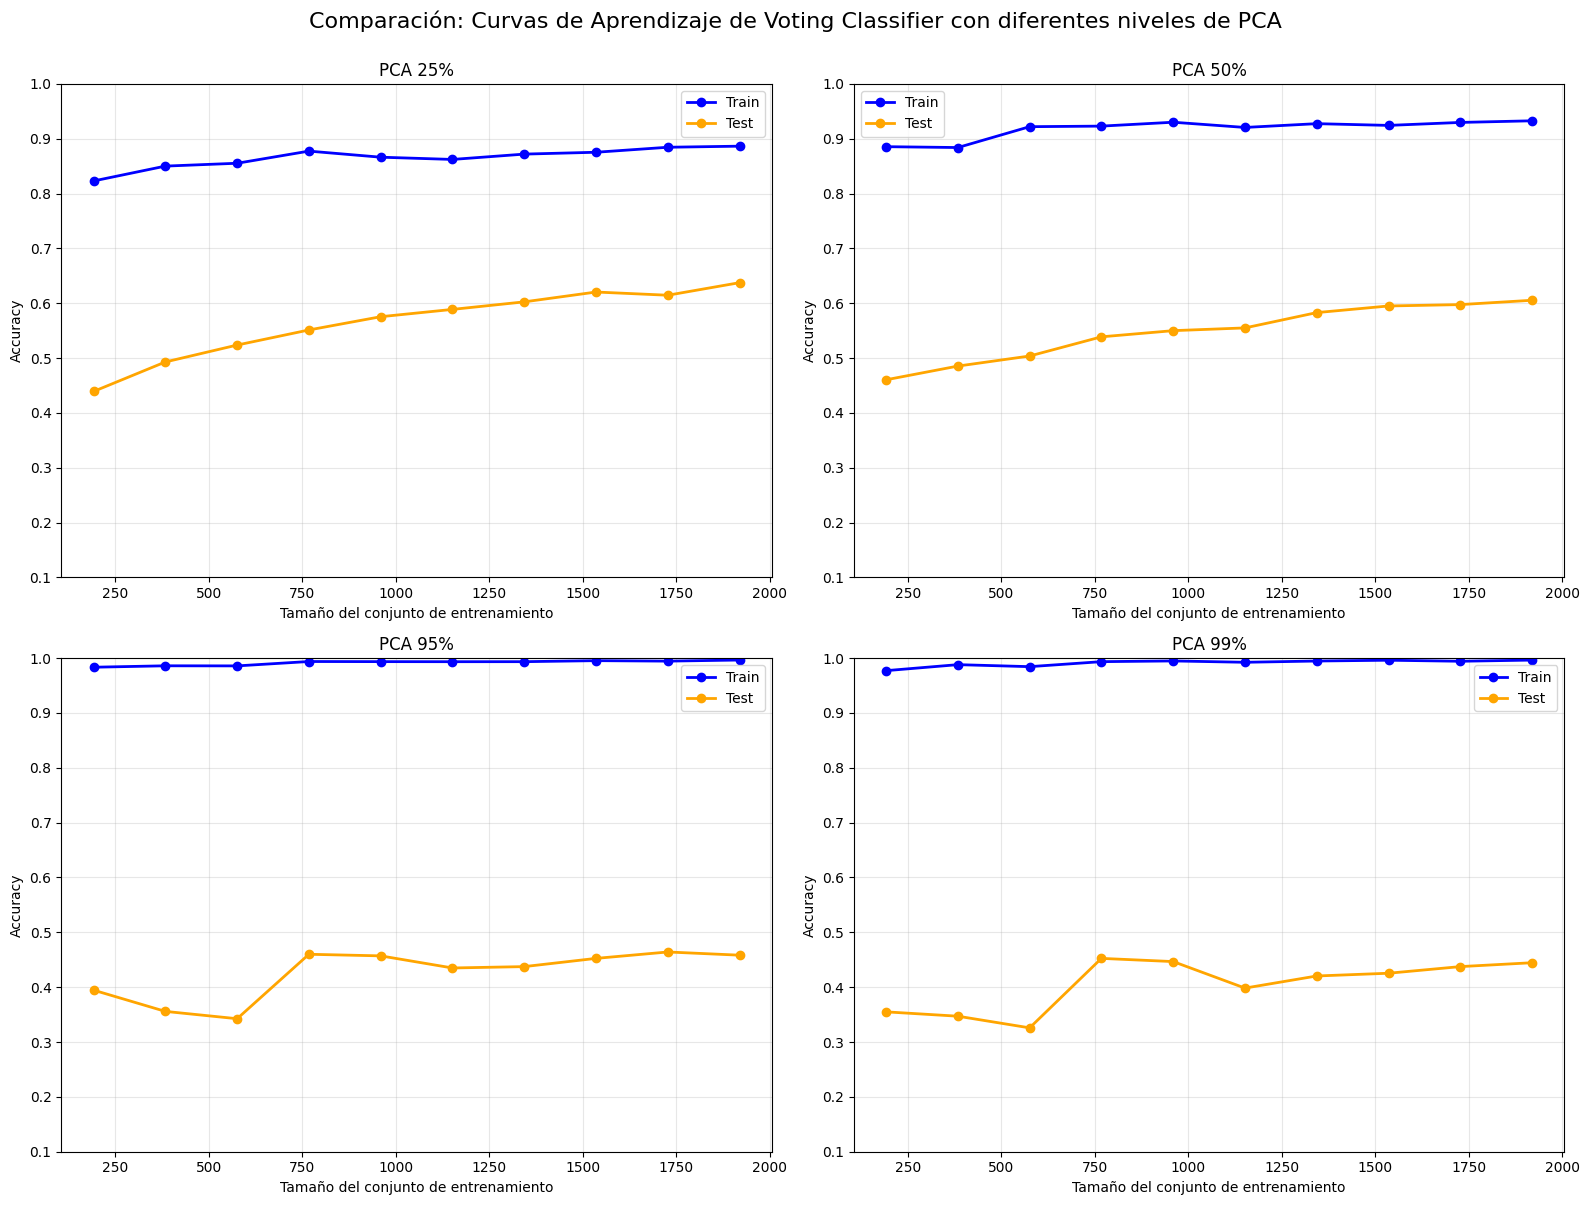

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import learning_curve
# Nota: Asume que las 4 pipes de voting, X_train y y_train están definidas.

# --- 1. Calcular curvas con diferentes niveles de PCA (VOTING) ---

# Calcular curvas con PCA 50%
train_sizes_50, train_scores_50, test_scores_50 = learning_curve(
    pipe_voting_50, X_train, y_train, cv=5, 
    train_sizes=np.linspace(0.1, 1.0, 10), 
    scoring='accuracy', n_jobs=-1
)

# Calcular curvas con PCA 25%
train_sizes_25, train_scores_25, test_scores_25 = learning_curve(
    pipe_voting_25, X_train, y_train, cv=5, 
    train_sizes=np.linspace(0.1, 1.0, 10), 
    scoring='accuracy', n_jobs=-1
)

# Calcular curvas con PCA 95%
train_sizes_95, train_scores_95, test_scores_95 = learning_curve(
    pipe_voting_95, X_train, y_train, cv=5, 
    train_sizes=np.linspace(0.1, 1.0, 10), 
    scoring='accuracy', n_jobs=-1
)

# Calcular curvas con PCA 99%
train_sizes_99, train_scores_99, test_scores_99 = learning_curve(
    pipe_voting_99, X_train, y_train, cv=5, 
    train_sizes=np.linspace(0.1, 1.0, 10), 
    scoring='accuracy', n_jobs=-1
)

# --- 2. Promediar los scores ---
train_mean_50 = train_scores_50.mean(axis=1)
test_mean_50 = test_scores_50.mean(axis=1)
train_mean_25 = train_scores_25.mean(axis=1)
test_mean_25 = test_scores_25.mean(axis=1)
train_mean_95 = train_scores_95.mean(axis=1)
test_mean_95 = test_scores_95.mean(axis=1)
train_mean_99 = train_scores_99.mean(axis=1)
test_mean_99 = test_scores_99.mean(axis=1)

# --- 3. Gráfico comparativo 2x2 ---
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Subplot 1: PCA 25%
axes[0, 0].plot(train_sizes_25, train_mean_25, 'o-', label='Train', color='blue', linewidth=2)
axes[0, 0].plot(train_sizes_25, test_mean_25, 'o-', label='Test', color='orange', linewidth=2)
axes[0, 0].set_xlabel('Tamaño del conjunto de entrenamiento')
axes[0, 0].set_ylabel('Accuracy')
axes[0, 0].set_title('PCA 25%')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)
axes[0, 0].set_ylim([0.1, 1.0])

# Subplot 2: PCA 50%
axes[0, 1].plot(train_sizes_50, train_mean_50, 'o-', label='Train', color='blue', linewidth=2)
axes[0, 1].plot(train_sizes_50, test_mean_50, 'o-', label='Test', color='orange', linewidth=2)
axes[0, 1].set_xlabel('Tamaño del conjunto de entrenamiento')
axes[0, 1].set_ylabel('Accuracy')
axes[0, 1].set_title('PCA 50%')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)
axes[0, 1].set_ylim([0.1, 1.0])

# Subplot 3: PCA 95%
axes[1, 0].plot(train_sizes_95, train_mean_95, 'o-', label='Train', color='blue', linewidth=2)
axes[1, 0].plot(train_sizes_95, test_mean_95, 'o-', label='Test', color='orange', linewidth=2)
axes[1, 0].set_xlabel('Tamaño del conjunto de entrenamiento')
axes[1, 0].set_ylabel('Accuracy')
axes[1, 0].set_title('PCA 95%')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)
axes[1, 0].set_ylim([0.1, 1.0])

# Subplot 4: PCA 99%
axes[1, 1].plot(train_sizes_99, train_mean_99, 'o-', label='Train', color='blue', linewidth=2)
axes[1, 1].plot(train_sizes_99, test_mean_99, 'o-', label='Test', color='orange', linewidth=2)
axes[1, 1].set_xlabel('Tamaño del conjunto de entrenamiento')
axes[1, 1].set_ylabel('Accuracy')
axes[1, 1].set_title('PCA 99%')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)
axes[1, 1].set_ylim([0.1, 1.0])

# Título actualizado
plt.suptitle('Comparación: Curvas de Aprendizaje de Voting Classifier con diferentes niveles de PCA', fontsize=16, y=1.00)
plt.tight_layout()
plt.show()

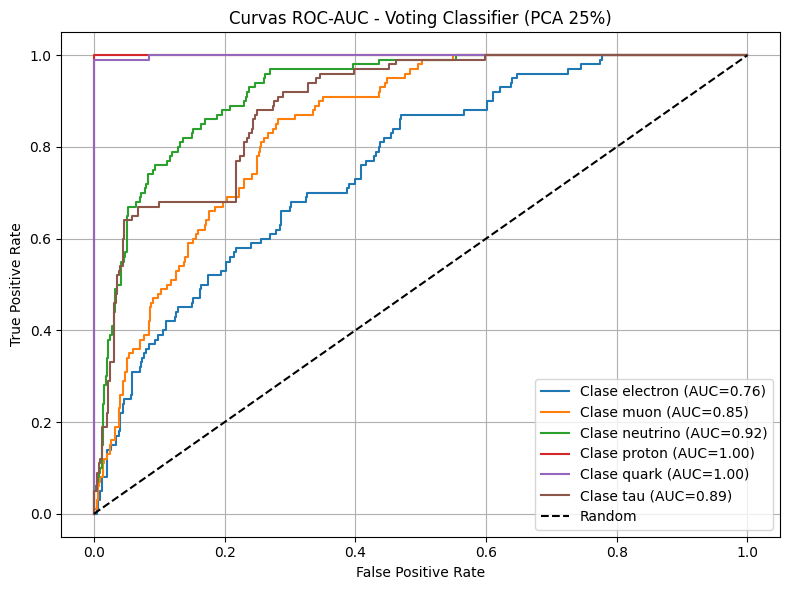

In [ ]:
y_test_bin = label_binarize(y_test, classes=class_names)

y_score = pipe_voting_25.predict_proba(X_test)

fpr = dict()
tpr = dict()
roc_auc = dict()

for i, clase in enumerate(class_names):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

plt.figure(figsize=(8, 6))
for i, clase in enumerate(class_names):
    plt.plot(fpr[i], tpr[i], label=f'Clase {clase} (AUC={roc_auc[i]:.2f})')

plt.plot([0, 1], [0, 1], 'k--', label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Curvas ROC-AUC - Voting Classifier (PCA 25%)') 
plt.legend(loc='lower right')
plt.grid(True)
plt.tight_layout()
plt.show()


Evaluación de Overfitting: Voting Classifier
Accuracy Train: 0.8892 | Test: 0.6583 | Diff: 0.2308
F1-Score Train: 0.8876 | Test: 0.6510 | Diff: 0.2367
OVERFITTING (diferencia >10%)


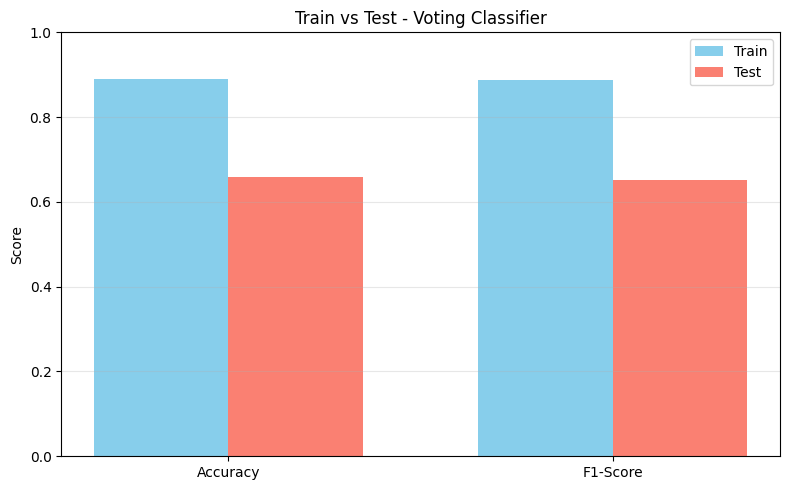

In [ ]:
evaluar_overfitting(pipe_voting_25, X_train, X_test, y_train, y_test, "Voting Classifier")

### 4.9 📚 STACKING CLASSIFIER (Opcional)

#### 4.9.1 Configuración y Entrenamiento

In [ ]:
clf_lr = LogisticRegression(**LR_PARAMS)
clf_dt = DecisionTreeClassifier(**DT_PARAMS)
clf_knn = KNeighborsClassifier(**KNN_PARAMS)
clf_nb = GaussianNB(**NB_PARAMS)

# --- 1. Definición del Meta-Clasificador Final ---
final_estimator = LogisticRegression(solver='saga', max_iter=2000, random_state=42) 

# --- 2. Definición del Stacking Classifier ---
stacking_clf = StackingClassifier(
    estimators=[
        ('lr', clf_lr),     
        ('dt', clf_dt),     
        ('knn', clf_knn),   
        ('nb', clf_nb)      
    ], 
    final_estimator=final_estimator, 
    cv=5, 
    n_jobs=-1
)

pipe_stacking_50 = Pipeline([
    ('scaler', StandardScaler()),
    ('pca', PCA(n_components=0.50)), 
    ('clf', stacking_clf) 
])

pipe_stacking_25 = Pipeline([
    ('scaler', StandardScaler()),
    ('pca', PCA(n_components=0.25)),
    ('clf', stacking_clf)
])

# Pipeline para PCA 95%
pipe_stacking_95 = Pipeline([
    ('scaler', StandardScaler()),
    ('pca', PCA(n_components=0.95)),
    ('clf', stacking_clf)
])

# Pipeline para PCA 99%
pipe_stacking_99 = Pipeline([
    ('scaler', StandardScaler()),
    ('pca', PCA(n_components=0.99)),
    ('clf', stacking_clf)
])

# pipe_stacking_50 ya está definido en tu código original.
# --- 3. Entrenamiento y Validación Cruzada ---
print("Iniciando entrenamiento del Stacking Classifier (LR, DT, kNN, NB | PCA 50%)...")
pipe_stacking_50.fit(X_train, y_train) 

cv_scores_stacking_50 = cross_val_score(pipe_stacking_50, X_train, y_train, cv=5, scoring='accuracy', n_jobs=-1) 
print('---')
print(f'Accuracy Stacking Classifier CV (5 folds, PCA 50%): {cv_scores_stacking_50.mean():.4f}')

Iniciando entrenamiento del Stacking Classifier (LR, DT, kNN, NB | PCA 50%)...
---
Accuracy Stacking Classifier CV (5 folds, PCA 50%): 0.5404


In [ ]:
y_pred = pipe_stacking_50.predict(X_test)
y_train_pred = pipe_stacking_50.predict(X_train)

# 2. Cálculo de Accuracy
acc_test = accuracy_score(y_test, y_pred)
acc_train = accuracy_score(y_train, y_train_pred)

# 3. Impresión de Métricas
print(f'Accuracy en train: {acc_train:.4f}')
print(f'Accuracy en test: {acc_test:.4f}')
# Usamos el score CV específico para el Stacking Classifier
print(f'Accuracy CV (5 folds): {cv_scores_stacking_50.mean():.4f}') 
print('\nReporte de clasificación:')

# 4. Reporte de Clasificación
print(classification_report(y_test, y_pred))

Accuracy en train: 0.8958
Accuracy en test: 0.5650
Accuracy CV (5 folds): 0.5404

Reporte de clasificación:
              precision    recall  f1-score   support

    electron       0.20      0.10      0.13       100
        muon       0.31      0.94      0.47       100
    neutrino       0.77      0.23      0.35       100
      proton       1.00      0.99      0.99       100
       quark       0.99      1.00      1.00       100
         tau       0.59      0.13      0.21       100

    accuracy                           0.56       600
   macro avg       0.64      0.56      0.53       600
weighted avg       0.64      0.56      0.53       600



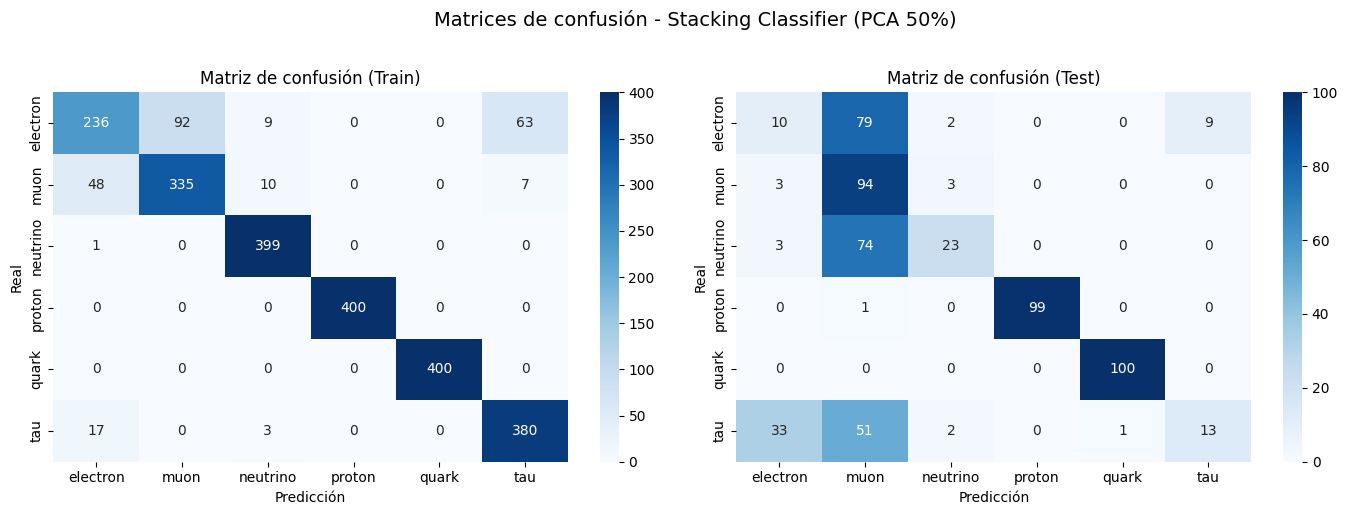

In [ ]:
# Usamos las predicciones del Stacking Classifier
cm_train = confusion_matrix(y_train, y_train_pred, labels=class_names)
cm_test = confusion_matrix(y_test, y_pred, labels=class_names)

# Creamos la figura con dos subgráficos
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Matriz de confusión Train
sns.heatmap(cm_train, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_names, yticklabels=class_names, ax=axes[0])
axes[0].set_xlabel('Predicción')
axes[0].set_ylabel('Real')
axes[0].set_title('Matriz de confusión (Train)')

# 2. Matriz de confusión Test
sns.heatmap(cm_test, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_names, yticklabels=class_names, ax=axes[1])
axes[1].set_xlabel('Predicción')
axes[1].set_ylabel('Real')
axes[1].set_title('Matriz de confusión (Test)')

# Título general actualizado para Stacking Classifier
plt.suptitle('Matrices de confusión - Stacking Classifier (PCA 50%)', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

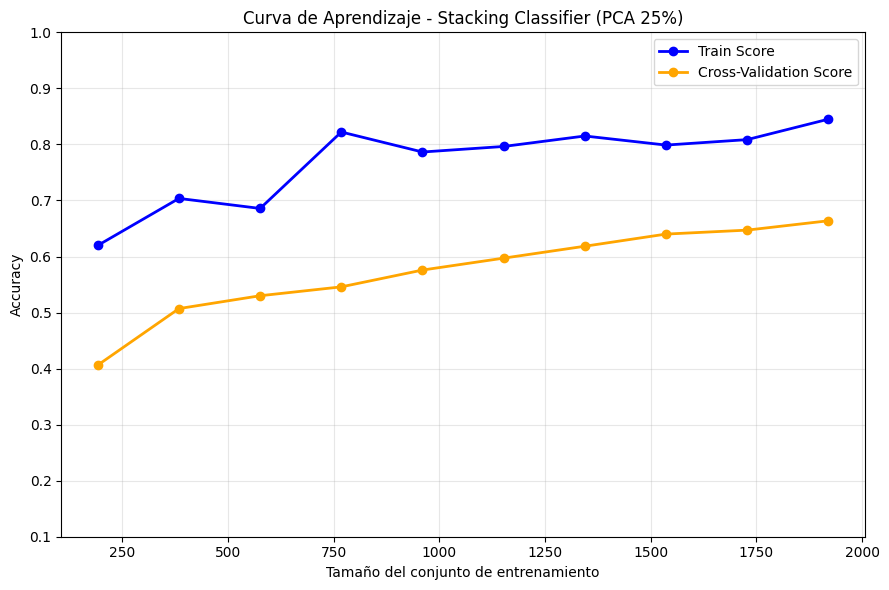

In [34]:
train_sizes_25, train_scores_25, test_scores_25 = learning_curve(
    pipe_stacking_25, X_train, y_train, cv=5, 
    train_sizes=np.linspace(0.1, 1.0, 10), 
    scoring='accuracy', 
    n_jobs=-1 # Usamos todos los núcleos para acelerar
)

# --- 2. Promediar los scores ---
train_mean_25 = train_scores_25.mean(axis=1)
test_mean_25 = test_scores_25.mean(axis=1)

# --- 3. Gráfico de Curva de Aprendizaje ---
plt.figure(figsize=(9, 6))

plt.plot(train_sizes_25, train_mean_25, 'o-', 
         label='Train Score', color='blue', linewidth=2)
plt.plot(train_sizes_25, test_mean_25, 'o-', 
         label='Cross-Validation Score', color='orange', linewidth=2)

plt.xlabel('Tamaño del conjunto de entrenamiento')
plt.ylabel('Accuracy')
plt.title('Curva de Aprendizaje - Stacking Classifier (PCA 25%)')
plt.legend(loc='best')
plt.grid(True, alpha=0.3)
plt.ylim([0.1, 1.0])

plt.tight_layout()
plt.show()

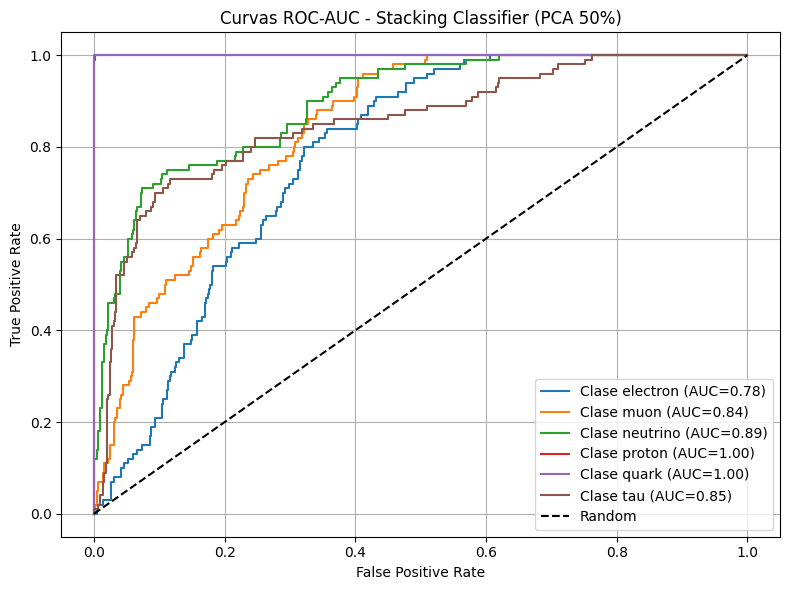

In [41]:
y_test_bin = label_binarize(y_test, classes=class_names)
y_score = pipe_stacking_50.predict_proba(X_test)

fpr = dict()
tpr = dict()
roc_auc = dict()

for i, clase in enumerate(class_names):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

plt.figure(figsize=(8, 6))
# Graficar todas las curvas ROC
for i, clase in enumerate(class_names):
    plt.plot(fpr[i], tpr[i], label=f'Clase {clase} (AUC={roc_auc[i]:.2f})')

# Graficar la línea de referencia
plt.plot([0, 1], [0, 1], 'k--', label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
# Título actualizado
plt.title('Curvas ROC-AUC - Stacking Classifier (PCA 50%)') 
plt.legend(loc='lower right')
plt.grid(True)
plt.tight_layout()
plt.show()


Evaluación de Overfitting: Stacking Classifier
Accuracy Train: 0.8958 | Test: 0.5650 | Diff: 0.3308
F1-Score Train: 0.8914 | Test: 0.5271 | Diff: 0.3644
OVERFITTING (diferencia >10%)


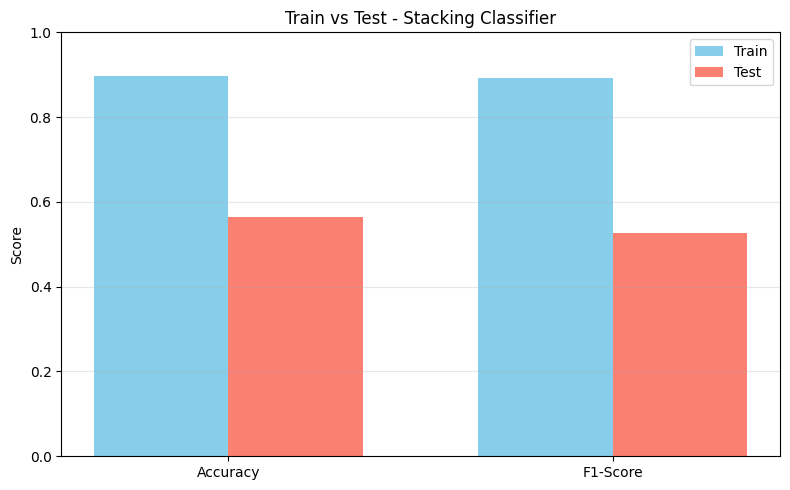

In [38]:
evaluar_overfitting(pipe_stacking_50, X_train, X_test, y_train, y_test, "Stacking Classifier")

---
### 4.10 🧠 PERCEPTRÓN (Opcional)

#### 4.10.1 Entrenamiento

#### 4.10.2 Evaluación y Métricas

---
### 4.11 🧠 MLP (Red Neuronal - Opcional)

#### 4.11.1 Configuración y Entrenamiento

#### 4.11.2 Evaluación y Métricas

---
## 📊 SECCIÓN 5: COMPARACIÓN FINAL DE MODELOS

### 5.1 Tabla comparativa de todos los modelos

### 5.2 Gráfico de barras comparativo

### 5.3 Mejor modelo

---
## 🔍 SECCIÓN 6: CLUSTERING (No Supervisado - Opcional)

### 6.1 K-Means

### 6.2 Visualización con PCA 2D

### 6.3 DBSCAN (opcional)

---
## 📝 SECCIÓN 7: CONCLUSIONES

### 7.1 Resumen de resultados

- **Mejor modelo:** 
- **Accuracy:** 
- **Análisis de overfitting:** 
- **Recomendaciones:** 

### 7.2 Posibles mejoras

1. Aumentar dataset con data augmentation
2. Probar otros hiperparámetros con RandomizedSearchCV
3. Feature engineering adicional
4. Probar redes neuronales convolucionales (CNN)
5. Ensemble de mejores modelos